# Integrated Capstone Project: Combined Notebook (Weeks 8–11)

## Overview

This notebook combines four weekly analyses (Weeks 8–11) of the Integrated Capstone Project into a single document. Two breast cancer datasets are analyzed side by side throughout:

1. **Breast Cancer Wisconsin (Diagnostic)** — tumor image-based measurements such as radius, texture, perimeter, area, smoothness, and concavity.
2. **Breast Cancer Coimbra** — clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

The datasets are **not merged** (they contain different patients and different variables). Instead, each method is applied to both datasets and the results are compared.

| Section | Week | Method family | Learning type |
|---|---|---|---|
| 2 | Week 8 | K-Nearest Neighbors & distance metrics | Supervised |
| 3 | Week 9 | Gradient boosting | Supervised |
| 4 | Week 10 | K-Means clustering | Unsupervised |
| 5 | Week 11 | DBSCAN & hierarchical clustering (HAC) | Unsupervised |

Each dataset is loaded **once** in Section 1 (Setup and data loading) and reused across all four weeks. Every week keeps its original Part A (Wisconsin) / Part B (Coimbra) / Part C (comparison) structure.

## 1. Setup and data loading

#### 1.1 Imports

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

#### 1.2 Load the Breast Cancer Wisconsin (Diagnostic) dataset

In [2]:
cancer = load_breast_cancer()

wisconsin_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
wisconsin_df.columns = wisconsin_df.columns.str.replace(" ", "_")

wisconsin_df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
wisconsin_df["diagnosis_label"] = np.where(wisconsin_df["diagnosis_malignant"] == 1, "Malignant", "Benign")

wisconsin_features = [
    col for col in wisconsin_df.columns
    if col not in ["diagnosis_malignant", "diagnosis_label"]
]

print("Wisconsin shape:", wisconsin_df.shape)
print(wisconsin_df["diagnosis_label"].value_counts())
wisconsin_df.head()

Wisconsin shape: (569, 32)
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


#### 1.3 Load the Breast Cancer Coimbra dataset

*Loaded from the UCI Machine Learning Repository (requires internet access).*

In [3]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"
coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", "breast_cancer_present", "diagnosis_group"]
]

print("Coimbra shape:", coimbra_df.shape)
print(coimbra_df["diagnosis_group"].value_counts())
coimbra_df.head()

Coimbra shape: (116, 12)
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


## 2. Week 8 — K-Nearest Neighbors & Distance Metrics

**Week topic:** K-Nearest Neighbors and distance metrics

#### Notebook purpose

For Week 8, I am applying **K-Nearest Neighbors (KNN)** to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements such as radius, texture, perimeter, area, smoothness, and concavity.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I am not merging these datasets because they are not from the same patients and do not have the same variables. Instead, I use them side-by-side to compare how a distance-based model behaves on two different types of breast cancer data.

This notebook focuses on:

- K-Nearest Neighbors classification
- Feature scaling for distance-based models
- Different values of `k`
- Distance metrics: Euclidean, Manhattan, Minkowski, and Chebyshev
- Uniform versus distance-weighted neighbors
- Cross-validation and hyperparameter tuning
- Comparison of Wisconsin and Coimbra results

#### Why KNN needs scaling

KNN is a distance-based model. It classifies a new observation by looking at the closest training observations. Because of that, feature scaling is very important.

If one feature has a much larger numeric range than another feature, it can dominate the distance calculation. For example, tumor area or MCP-1 may have much larger values than smoothness or BMI. Without scaling, KNN may treat large-scale variables as more important just because of their units.

In this notebook, I compare KNN with and without scaling, but I expect the scaled versions to be more appropriate.


#### Helper functions

I use the same helper functions for both datasets so the comparison is consistent.

In [4]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    """Fit a classifier and return common binary classification metrics."""
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_positive": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_positive": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_positive": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_pred, test_pred, train_prob, test_prob


def plot_decision_boundary(model, X_data, y_data, title, class_labels, x_pad=1, y_pad=1):
    """Plot a 2-feature decision boundary for a fitted classifier pipeline."""
    x_min, x_max = X_data.iloc[:, 0].min() - x_pad, X_data.iloc[:, 0].max() + x_pad
    y_min, y_max = X_data.iloc[:, 1].min() - y_pad, X_data.iloc[:, 1].max() + y_pad

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 250),
        np.linspace(y_min, y_max, 250)
    )

    grid_points = pd.DataFrame({
        X_data.columns[0]: xx.ravel(),
        X_data.columns[1]: yy.ravel()
    })

    Z = model.predict(grid_points).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)

    for class_value, label in class_labels:
        plt.scatter(
            X_data.iloc[y_data.values == class_value, 0],
            X_data.iloc[y_data.values == class_value, 1],
            label=label,
            alpha=0.8
        )

    plt.xlabel(X_data.columns[0])
    plt.ylabel(X_data.columns[1])
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_knn_workflow(dataset_name, df, feature_cols, target_col, label_col, positive_class_name, negative_class_name, two_feature_cols):
    """Run the Week 8 KNN workflow for one dataset."""
    print("=" * 80)
    print(f"KNN workflow for {dataset_name}")
    print("=" * 80)

    X = df[feature_cols]
    y = df[target_col]

    print("Dataset shape:", df.shape)
    print("Number of features:", X.shape[1])
    print("\nClass counts:")
    print(df[label_col].value_counts())
    print("\nClass percentages:")
    print(df[label_col].value_counts(normalize=True).round(3))

    # EDA: correlations with target
    corr_with_target = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
    corr_sorted = corr_with_target.sort_values()

    plt.figure(figsize=(9, 6))
    plt.barh(corr_sorted.index, corr_sorted.values)
    plt.xlabel(f"Correlation With {positive_class_name}")
    plt.title(f"{dataset_name}: Feature Correlations With Target")
    plt.tight_layout()
    plt.show()

    # EDA: feature ranges
    scale_summary = X.agg(["min", "max", "mean", "std"]).T
    scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
    scale_summary_plot = scale_summary.sort_values("range", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(scale_summary_plot.index, scale_summary_plot["range"])
    plt.xlabel("Feature Range")
    plt.title(f"{dataset_name}: Feature Ranges Before Scaling")
    plt.tight_layout()
    plt.show()

    display(scale_summary.sort_values("range", ascending=False))

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("\nTraining shape:", X_train.shape)
    print("Testing shape:", X_test.shape)

    # Baseline no scaling
    knn_no_scaling = Pipeline(steps=[
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    no_scaling_results, no_scaling_train_pred, no_scaling_test_pred, no_scaling_train_prob, no_scaling_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: No Scaling, k=5",
        knn_no_scaling,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # Standard scaling
    knn_standard = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    standard_results, standard_train_pred, standard_test_pred, standard_train_prob, standard_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: Standard Scaled, k=5",
        knn_standard,
        X_train,
        X_test,
        y_train,
        y_test
    )

    # Min-max scaling
    knn_minmax = Pipeline(steps=[
        ("scaler", MinMaxScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])

    minmax_results, minmax_train_pred, minmax_test_pred, minmax_train_prob, minmax_test_prob = evaluate_classifier(
        f"{dataset_name} KNN: Min-Max Scaled, k=5",
        knn_minmax,
        X_train,
        X_test,
        y_train,
        y_test
    )

    scaling_results_df = pd.DataFrame([
        no_scaling_results,
        standard_results,
        minmax_results
    ]).sort_values("test_roc_auc", ascending=False)

    print("\nScaling comparison:")
    display(scaling_results_df)

    plt.figure(figsize=(9, 5))
    plt.bar(scaling_results_df["model"], scaling_results_df["test_roc_auc"])
    plt.ylabel("Test ROC-AUC")
    plt.title(f"{dataset_name}: KNN Scaling Comparison by ROC-AUC")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # Hyperparameter tuning
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    tuned_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ])

    knn_param_grid = [
        {
            "model__n_neighbors": list(range(1, 22, 2)),
            "model__weights": ["uniform", "distance"],
            "model__metric": ["minkowski"],
            "model__p": [1, 2]
        },
        {
            "model__n_neighbors": list(range(1, 22, 2)),
            "model__weights": ["uniform", "distance"],
            "model__metric": ["chebyshev"]
        }
    ]

    grid = GridSearchCV(
        estimator=tuned_pipe,
        param_grid=knn_param_grid,
        scoring="recall",
        cv=cv,
        n_jobs=1
    )

    grid.fit(X_train, y_train)

    print("\nBest KNN parameters:")
    print(grid.best_params_)
    print("Best cross-validated recall:", grid.best_score_)

    tuned_results, tuned_train_pred, tuned_test_pred, tuned_train_prob, tuned_test_prob = evaluate_classifier(
        f"{dataset_name} Tuned KNN",
        grid.best_estimator_,
        X_train,
        X_test,
        y_train,
        y_test
    )

    model_results_df = pd.DataFrame([
        no_scaling_results,
        standard_results,
        minmax_results,
        tuned_results
    ]).sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])

    print("\nKNN model comparison:")
    display(model_results_df)

    # k sensitivity
    k_results = []

    for k in range(1, 32, 2):
        model = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=2))
        ])

        recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

        k_results.append({
            "k": k,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

    k_results_df = pd.DataFrame(k_results)

    plt.figure(figsize=(8, 5))
    plt.plot(k_results_df["k"], k_results_df["CV_recall_mean"], marker="o", label="Recall")
    plt.plot(k_results_df["k"], k_results_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Cross-Validated Score")
    plt.title(f"{dataset_name}: KNN Sensitivity to k")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Distance metric comparison
    best_k = grid.best_params_["model__n_neighbors"]

    metric_models = {
        "Euclidean": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2))
        ]),
        "Manhattan": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=1))
        ]),
        "Chebyshev": Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=best_k, metric="chebyshev"))
        ])
    }

    metric_results = []

    for metric_name, model in metric_models.items():
        recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")

        metric_results.append({
            "distance_metric": metric_name,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

    metric_results_df = pd.DataFrame(metric_results).sort_values("CV_recall_mean", ascending=False)

    print("\nDistance metric comparison:")
    display(metric_results_df)

    plt.figure(figsize=(8, 5))
    plt.bar(metric_results_df["distance_metric"], metric_results_df["CV_recall_mean"], yerr=metric_results_df["CV_recall_std"], capsize=4)
    plt.ylabel("Cross-Validated Recall")
    plt.title(f"{dataset_name}: KNN Distance Metric Comparison")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

    # Final evaluation
    print("\nClassification report for tuned KNN:")
    print(classification_report(y_test, tuned_test_pred, target_names=[negative_class_name, positive_class_name]))

    cm = confusion_matrix(y_test, tuned_test_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[negative_class_name, positive_class_name]
    )
    disp.plot()
    plt.title(f"{dataset_name}: Confusion Matrix for Tuned KNN")
    plt.tight_layout()
    plt.show()

    RocCurveDisplay.from_estimator(grid.best_estimator_, X_test, y_test)
    plt.title(f"{dataset_name}: ROC Curve for Tuned KNN")
    plt.tight_layout()
    plt.show()

    # 2-feature visualization
    X_two = df[two_feature_cols]
    y_two = df[target_col]

    X_two_train, X_two_test, y_two_train, y_two_test = train_test_split(
        X_two,
        y_two,
        test_size=0.20,
        random_state=42,
        stratify=y_two
    )

    two_feature_model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=best_k))
    ])

    two_feature_model.fit(X_two_train, y_two_train)

    print("\nTwo-feature KNN accuracy:", accuracy_score(y_two_test, two_feature_model.predict(X_two_test)))

    plot_decision_boundary(
        two_feature_model,
        X_two,
        y_two,
        f"{dataset_name}: KNN Decision Regions Using Two Features",
        [(0, negative_class_name), (1, positive_class_name)],
        x_pad=1 if dataset_name == "Wisconsin" else 5,
        y_pad=0.05 if dataset_name == "Wisconsin" else 5
    )

    return {
        "dataset_name": dataset_name,
        "X": X,
        "y": y,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "grid": grid,
        "results_df": model_results_df,
        "k_results_df": k_results_df,
        "metric_results_df": metric_results_df,
        "tuned_results": tuned_results,
        "best_params": grid.best_params_
    }


### Part A — Wisconsin (Diagnostic)

#### Load and prepare Wisconsin dataset

The sklearn version of this dataset originally uses `0 = malignant` and `1 = benign`. I switch it so the positive class is malignant diagnosis:

- `diagnosis_malignant = 1` for malignant tumors
- `diagnosis_malignant = 0` for benign tumors


#### Run KNN workflow for Wisconsin

For Wisconsin, the two-feature visualization uses `mean_radius` and `mean_concavity`. These features were useful in earlier notebooks because they relate to tumor size and shape.

KNN workflow for Wisconsin
Dataset shape: (569, 32)
Number of features: 30

Class counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

Class percentages:
diagnosis_label
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


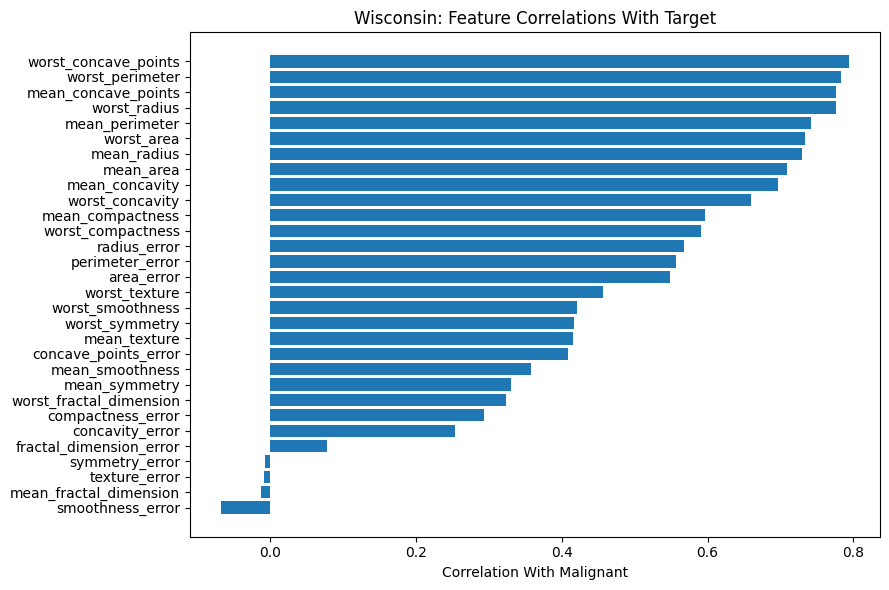

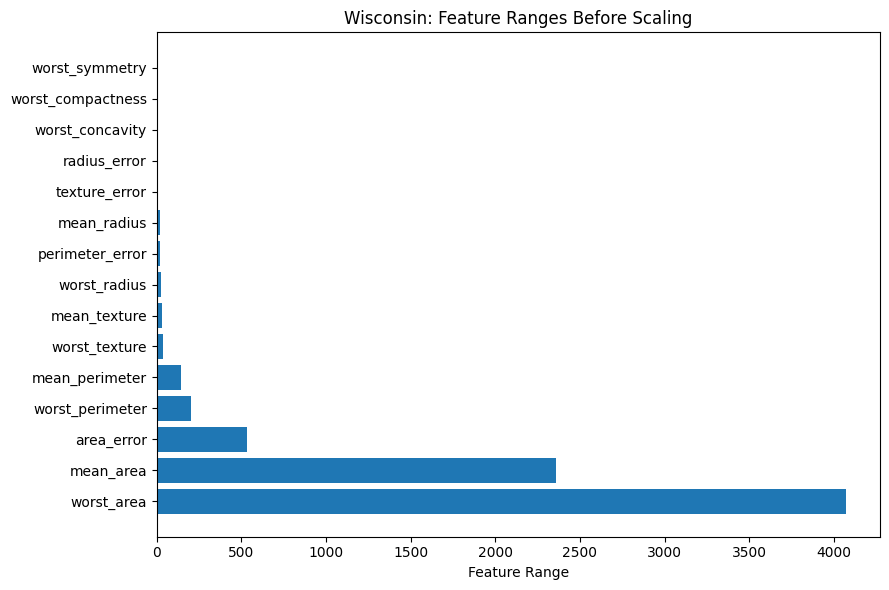

,min,max,mean,std,range
worst_area,185.200000,4254.00000,880.583128,569.356993,4068.800000
mean_area,143.500000,2501.00000,654.889104,351.914129,2357.500000
area_error,6.802000,542.20000,40.337079,45.491006,535.398000
worst_perimeter,50.410000,251.20000,107.261213,33.602542,200.790000
mean_perimeter,43.790000,188.50000,91.969033,24.298981,144.710000
worst_texture,12.020000,49.54000,25.677223,6.146258,37.520000
mean_texture,9.710000,39.28000,19.289649,4.301036,29.570000
worst_radius,7.930000,36.04000,16.269190,4.833242,28.110000
perimeter_error,0.757000,21.98000,2.866059,2.021855,21.223000
mean_radius,6.981000,28.11000,14.127292,3.524049,21.129000



Training shape: (455, 30)
Testing shape: (114, 30)

Scaling comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308
0,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696


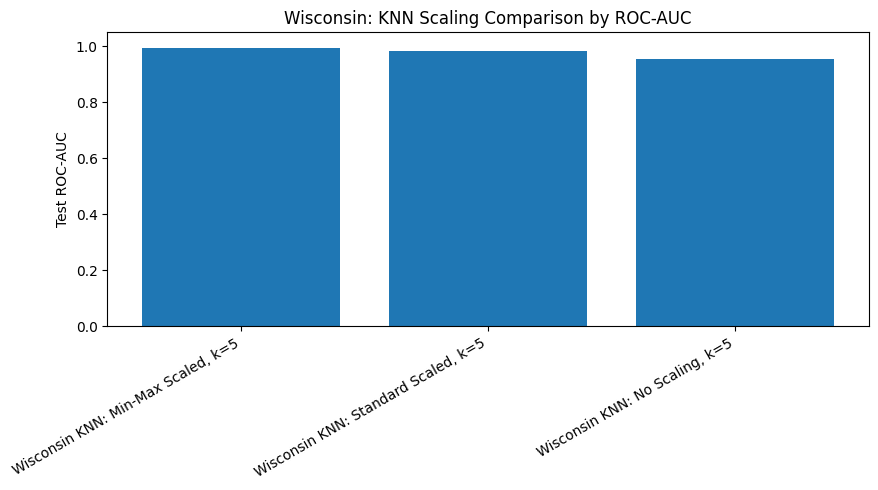


Best KNN parameters:
{'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}
Best cross-validated recall: 0.9470588235294117

KNN model comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308
3,Wisconsin Tuned KNN,0.984615,0.964912,1.000000,0.904762,0.950000,0.973545
0,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696


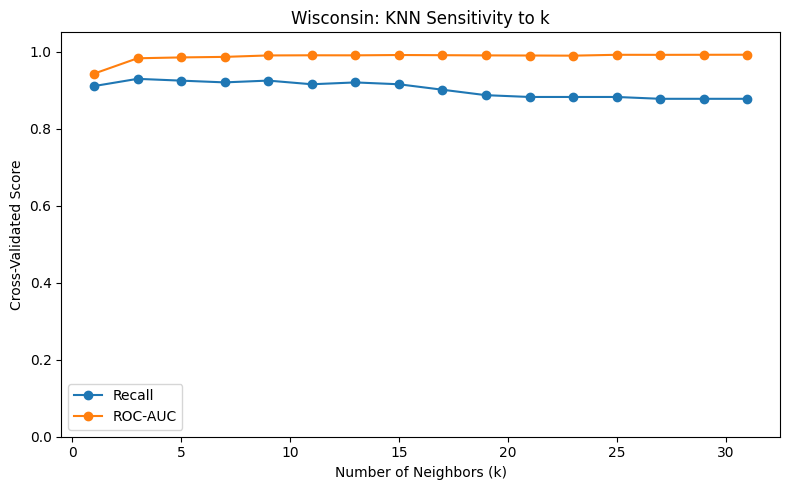


Distance metric comparison:


,distance_metric,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,Manhattan,0.938538,0.051006,0.983346,0.015528
0,Euclidean,0.929236,0.049531,0.982643,0.013364
2,Chebyshev,0.896346,0.043343,0.968564,0.017692


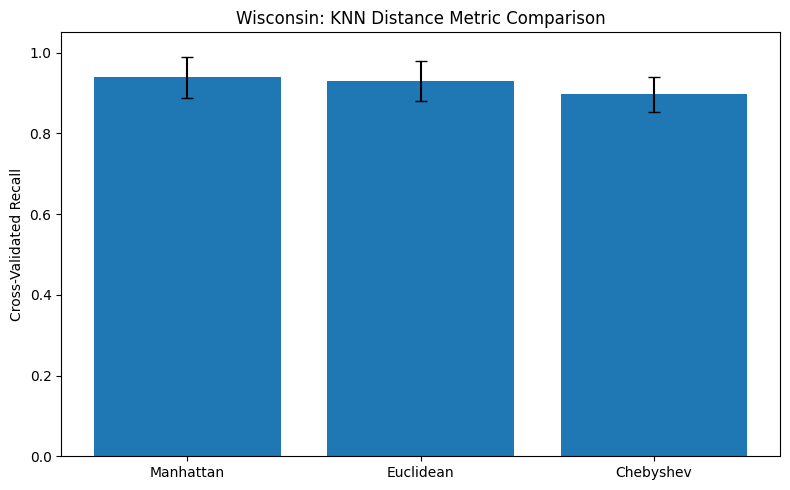


Classification report for tuned KNN:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



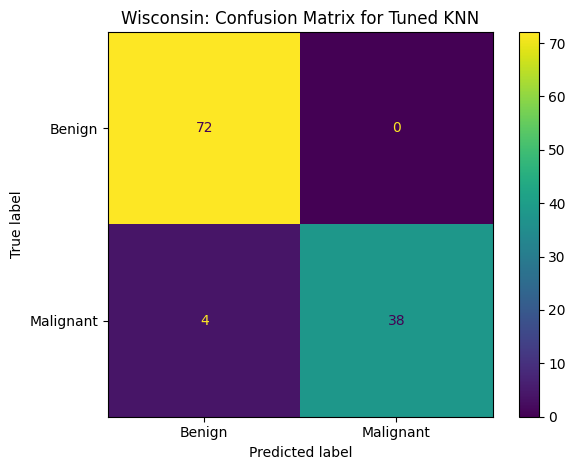

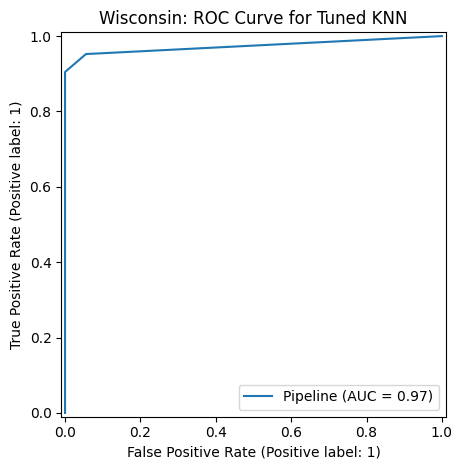


Two-feature KNN accuracy: 0.9122807017543859


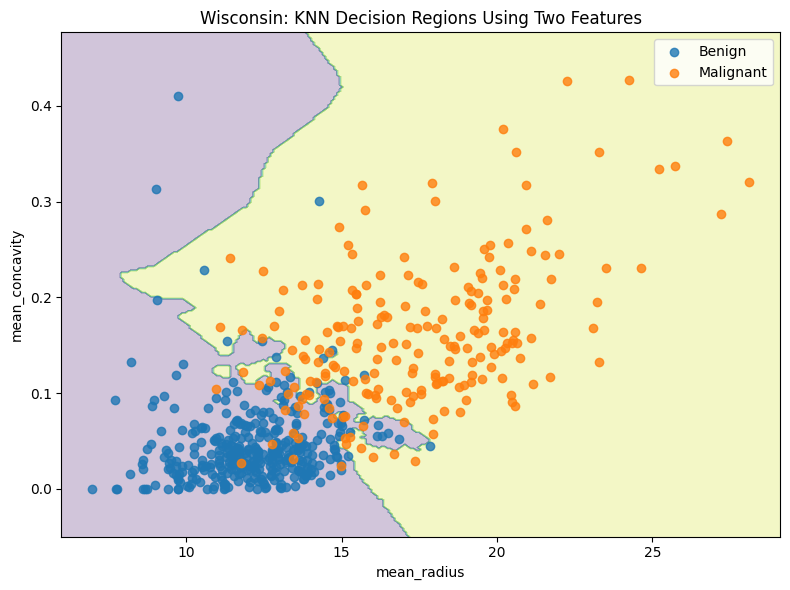

In [5]:
wisconsin_results = run_knn_workflow(
    dataset_name="Wisconsin",
    df=wisconsin_df,
    feature_cols=wisconsin_features,
    target_col="diagnosis_malignant",
    label_col="diagnosis_label",
    positive_class_name="Malignant",
    negative_class_name="Benign",
    two_feature_cols=["mean_radius", "mean_concavity"]
)


#### Wisconsin KNN interpretation

For Wisconsin, I expected KNN to perform well because the tumor measurements show strong separation between benign and malignant cases. Features like radius, perimeter, area, and concavity create meaningful distance patterns.

The key lesson is that scaling matters. Since KNN calculates distances, unscaled tumor area or perimeter could dominate the model just because those features have larger numeric values. Tuning `k` also matters because a small `k` can overfit, while a very large `k` can smooth too much and underfit.


### Part B — Coimbra (clinical & blood biomarkers)

#### Load and prepare Coimbra dataset

The Coimbra dataset target is called `Classification`. The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls


#### Run KNN workflow for Coimbra

For Coimbra, the two-feature visualization uses `Glucose` and `Resistin`. These are not the only important predictors, but they help show how KNN creates decision regions with clinical biomarkers.

KNN workflow for Coimbra
Dataset shape: (116, 12)
Number of features: 9

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64


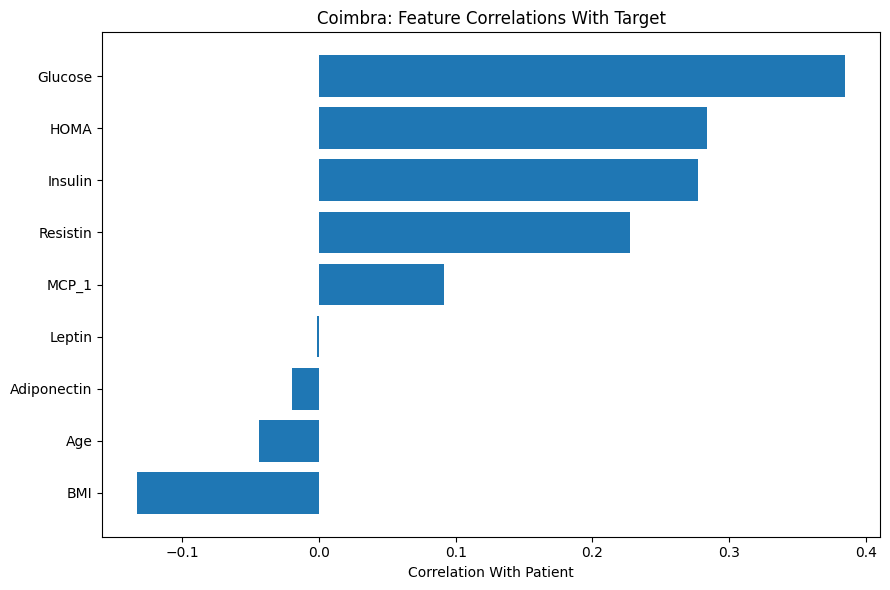

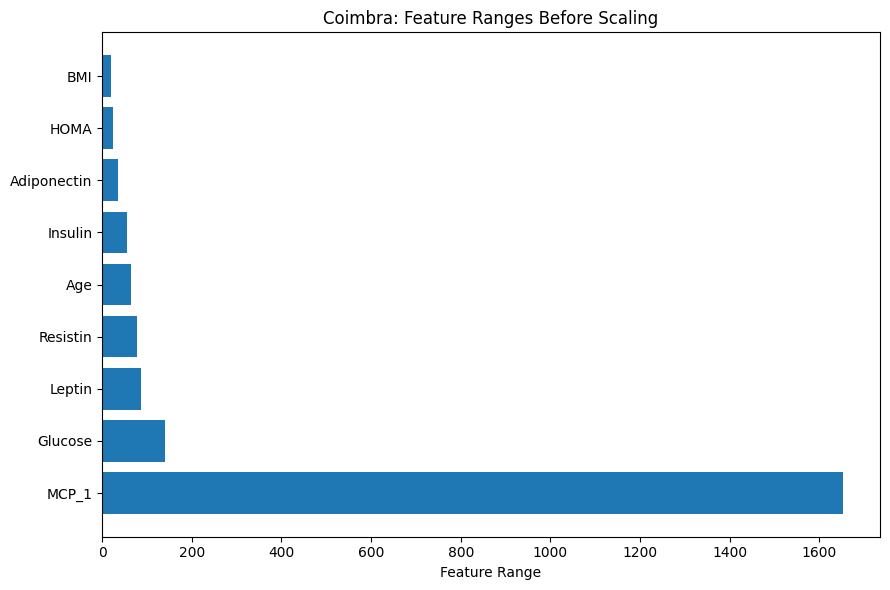

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759



Training shape: (92, 9)
Testing shape: (24, 9)

Scaling comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
1,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650
2,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168
0,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448


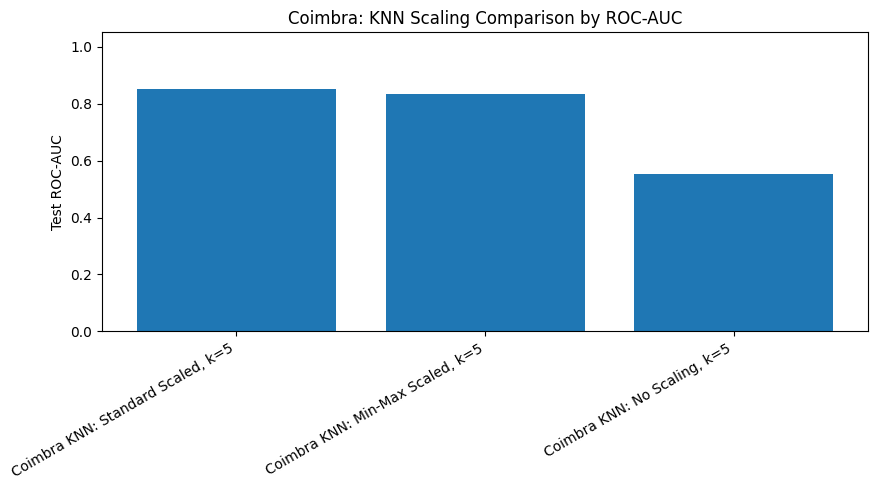


Best KNN parameters:
{'model__metric': 'chebyshev', 'model__n_neighbors': 19, 'model__weights': 'uniform'}
Best cross-validated recall: 0.8036363636363635

KNN model comparison:


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
2,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168
1,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650
3,Coimbra Tuned KNN,0.728261,0.666667,0.666667,0.769231,0.714286,0.685315
0,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448


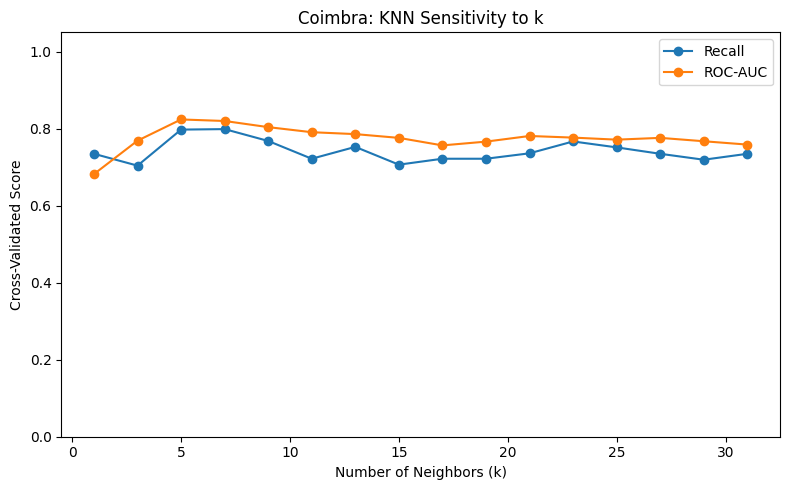


Distance metric comparison:


,distance_metric,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
2,Chebyshev,0.766667,0.095390,0.720082,0.087479
0,Euclidean,0.721795,0.112908,0.766224,0.084958
1,Manhattan,0.720513,0.140535,0.829825,0.093931


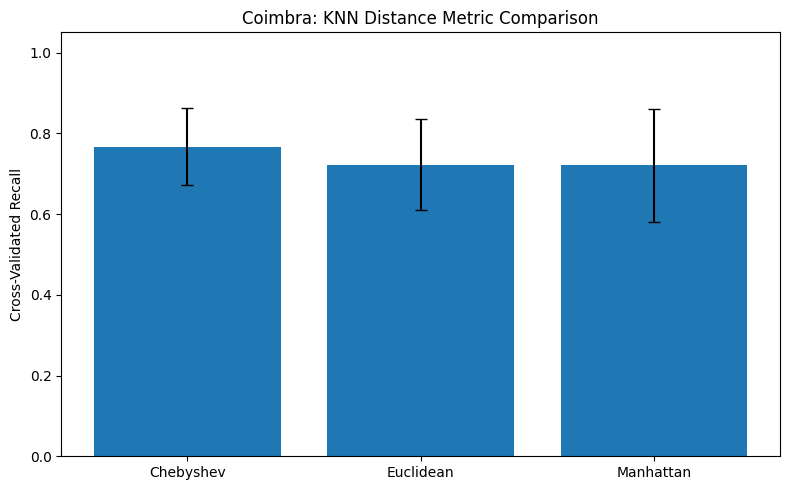


Classification report for tuned KNN:
                 precision    recall  f1-score   support

Healthy Control       0.67      0.55      0.60        11
        Patient       0.67      0.77      0.71        13

       accuracy                           0.67        24
      macro avg       0.67      0.66      0.66        24
   weighted avg       0.67      0.67      0.66        24



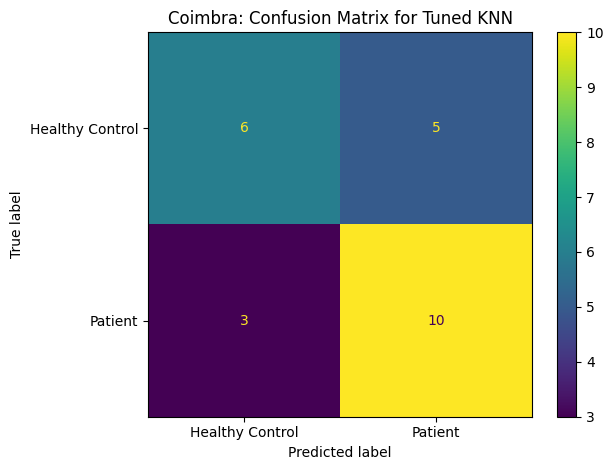

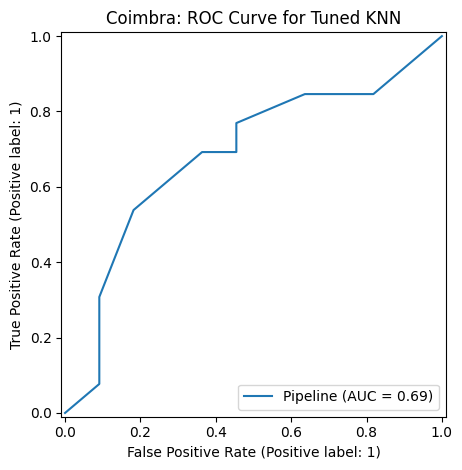


Two-feature KNN accuracy: 0.6666666666666666


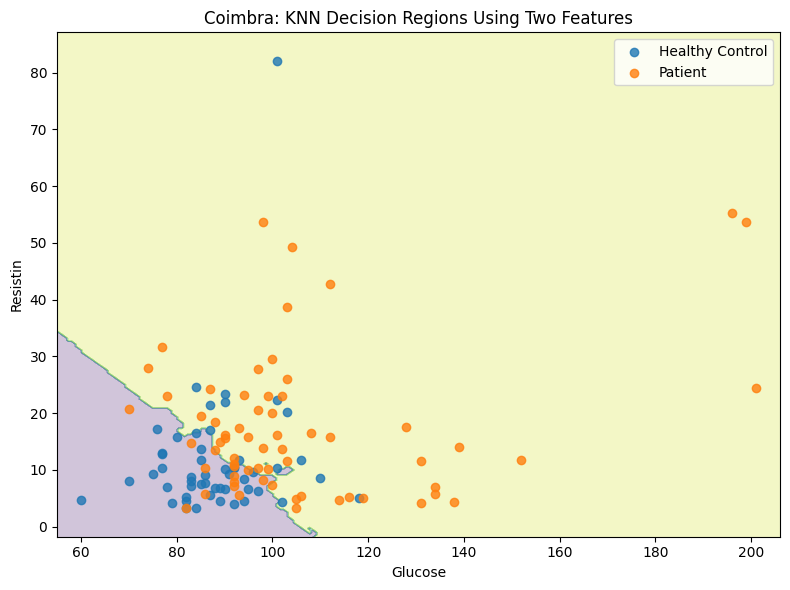

In [6]:
coimbra_results = run_knn_workflow(
    dataset_name="Coimbra",
    df=coimbra_df,
    feature_cols=coimbra_features,
    target_col="breast_cancer_present",
    label_col="diagnosis_group",
    positive_class_name="Patient",
    negative_class_name="Healthy Control",
    two_feature_cols=["Glucose", "Resistin"]
)


#### Coimbra KNN interpretation

For Coimbra, I expected KNN to be more challenging than Wisconsin because the dataset is smaller and the predictors are more indirect. KNN can still be useful because it compares similar patient profiles based on distance.

However, because Coimbra has fewer rows, the value of `k` and the distance metric can have a larger effect on the results. Cross-validation is important because one train-test split may not be stable enough.


### Part C — Comparison across both datasets

#### Compare Wisconsin and Coimbra KNN results

In [7]:
wisconsin_knn_results_df = wisconsin_results["results_df"].copy()
wisconsin_knn_results_df["dataset"] = "Wisconsin"

coimbra_knn_results_df = coimbra_results["results_df"].copy()
coimbra_knn_results_df["dataset"] = "Coimbra"

week8_combined_results = pd.concat(
    [wisconsin_knn_results_df, coimbra_knn_results_df],
    ignore_index=True
)

week8_combined_results.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc,dataset
0,"Wisconsin KNN: Min-Max Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.995701,Wisconsin
1,"Wisconsin KNN: Standard Scaled, k=5",0.978022,0.956140,0.974359,0.904762,0.938272,0.982308,Wisconsin
2,Wisconsin Tuned KNN,0.984615,0.964912,1.000000,0.904762,0.950000,0.973545,Wisconsin
4,"Coimbra KNN: Min-Max Scaled, k=5",0.782609,0.791667,0.785714,0.846154,0.814815,0.832168,Coimbra
3,"Wisconsin KNN: No Scaling, k=5",0.949451,0.912281,0.970588,0.785714,0.868421,0.954696,Wisconsin
5,"Coimbra KNN: Standard Scaled, k=5",0.836957,0.833333,0.909091,0.769231,0.833333,0.849650,Coimbra
6,Coimbra Tuned KNN,0.728261,0.666667,0.666667,0.769231,0.714286,0.685315,Coimbra
7,"Coimbra KNN: No Scaling, k=5",0.684783,0.541667,0.562500,0.692308,0.620690,0.552448,Coimbra


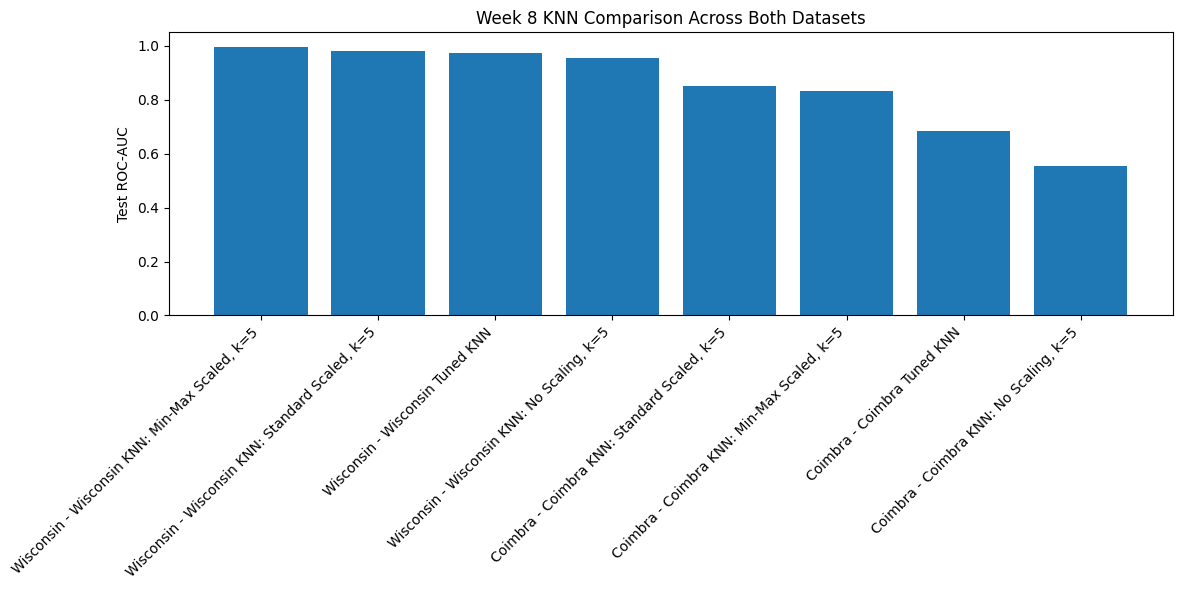

In [8]:
# Combined model comparison by ROC-AUC
plot_df = week8_combined_results.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset"] + " - " + plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Week 8 KNN Comparison Across Both Datasets")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Week 8 summary

This cell prints a short summary using the actual notebook results. I can use this later when writing Milestone Two.

In [9]:
best_w_knn = wisconsin_knn_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_knn = coimbra_knn_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

print("Week 8 KNN Summary")


print("Best Wisconsin KNN model:")
print(best_w_knn["model"])
print(f"Test accuracy: {best_w_knn['test_accuracy']:.4f}")
print(f"Test recall for malignant cases: {best_w_knn['test_recall_positive']:.4f}")
print(f"Test precision for malignant cases: {best_w_knn['test_precision_positive']:.4f}")
print(f"Test F1: {best_w_knn['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_w_knn['test_roc_auc']:.4f}")

print("\nBest Coimbra KNN model:")
print(best_c_knn["model"])
print(f"Test accuracy: {best_c_knn['test_accuracy']:.4f}")
print(f"Test recall for patients: {best_c_knn['test_recall_positive']:.4f}")
print(f"Test precision for patients: {best_c_knn['test_precision_positive']:.4f}")
print(f"Test F1: {best_c_knn['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_c_knn['test_roc_auc']:.4f}")

print("\nBest Wisconsin KNN hyperparameters:")
print(wisconsin_results["best_params"])

print("\nBest Coimbra KNN hyperparameters:")
print(coimbra_results["best_params"])


Week 8 KNN Summary
Best Wisconsin KNN model:
Wisconsin KNN: Min-Max Scaled, k=5
Test accuracy: 0.9561
Test recall for malignant cases: 0.9048
Test precision for malignant cases: 0.9744
Test F1: 0.9383
Test ROC-AUC: 0.9957

Best Coimbra KNN model:
Coimbra KNN: Min-Max Scaled, k=5
Test accuracy: 0.7917
Test recall for patients: 0.8462
Test precision for patients: 0.7857
Test F1: 0.8148
Test ROC-AUC: 0.8322

Best Wisconsin KNN hyperparameters:
{'model__metric': 'minkowski', 'model__n_neighbors': 3, 'model__p': 1, 'model__weights': 'uniform'}

Best Coimbra KNN hyperparameters:
{'model__metric': 'chebyshev', 'model__n_neighbors': 19, 'model__weights': 'uniform'}


#### Week 8 findings and interpretation

After running this Week 8 notebook, I learned that KNN is very different from models like logistic regression, decision trees, and random forests. KNN does not build a traditional equation or a tree. Instead, it classifies a new case based on the most similar cases in the training data.

The most important Week 8 lesson was that **distance matters**. Because KNN uses distances between observations, feature scaling is not optional. It directly affects which cases count as nearest neighbors. In both datasets, features had very different numeric ranges, so scaling was necessary.

For the **Wisconsin dataset**, I expected KNN to perform well because tumor measurements are strong predictors of diagnosis. Features like radius, perimeter, area, and concavity create meaningful distance patterns between benign and malignant cases.

For the **Coimbra dataset**, I expected performance to be less stable because the dataset is smaller and the predictors are more indirect. KNN can still be useful because it compares similar patient profiles, but the results depend heavily on `k`, scaling, and distance metric.

I used cross-validation to tune `k`, distance metric, and neighbor weighting. A small `k` can overfit because the model reacts too much to individual cases. A larger `k` smooths the decision boundary but can underfit if it averages over too many neighbors. Distance weighting can help because closer neighbors have more influence than farther neighbors.

Overall, KNN helped me compare how distance-based classification works on image-based tumor data versus clinical biomarker data. It also reinforced the importance of preprocessing, especially scaling, in healthcare machine learning.


#### Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is likely better suited for KNN because it has more rows and direct tumor morphology features. The Coimbra dataset is still useful, but because it is smaller and uses indirect biomarkers, the nearest-neighbor relationships may be less clear.

This comparison is useful for my capstone because it shows that the type of healthcare data matters. Tumor image measurements appear more directly connected to diagnosis, while clinical biomarkers may provide additional but less direct predictive information.

For Milestone Two, I can use this notebook to discuss how KNN performance depended strongly on feature scaling and distance metrics.


## 3. Week 9 — Gradient Boosting

**Week topic:** Gradient boosting, learning rate, number of estimators, tree depth, and regularization

#### Notebook purpose

For Week 9, I am applying **gradient boosting classification** to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset**  
   This dataset uses tumor image-based measurements such as radius, texture, perimeter, area, smoothness, concavity, and symmetry.

2. **Breast Cancer Coimbra dataset**  
   This dataset uses clinical and blood-based biomarkers such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1.

I am not merging the two datasets because they do not contain the same patients or the same variables. Instead, I am using the same modeling approach on each dataset and comparing the results.

For this week, I focus on:

- Gradient boosting classification
- Learning rate
- Number of estimators
- Tree depth
- Regularization through shrinkage, shallow trees, subsampling, and minimum samples per leaf
- Hyperparameter tuning with cross-validation
- Feature importance and model interpretation

Since both datasets have binary outcomes, this is a classification task. For Wisconsin, the positive class is malignant diagnosis. For Coimbra, the positive class is breast cancer patient.

#### Why gradient boosting is useful for this project

Gradient boosting builds an ensemble of many small decision trees. Each new tree tries to correct the mistakes made by the earlier trees. This can create a strong predictive model because the model learns gradually.

For this breast cancer project, gradient boosting is useful because:

- It can capture nonlinear relationships.
- It can capture interactions between features.
- It can work well with tabular healthcare data.
- It provides feature importance scores.

The main risk is overfitting. If the model uses too many trees, trees that are too deep, or a learning rate that is too aggressive, it may memorize the training data instead of generalizing.


#### Evaluation helper function

I use the same evaluation function for both datasets.

The metrics are:

- Accuracy
- Precision for the positive class
- Recall for the positive class
- F1-score
- ROC-AUC

For this project, recall is especially important because missing a cancer case would be a serious concern.


In [10]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_positive": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_positive": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_positive": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_pred, test_pred, train_prob, test_prob


### Part A — Wisconsin (Diagnostic)

#### Load and prepare Wisconsin dataset

The sklearn version of this dataset originally uses:

- `0 = malignant`
- `1 = benign`

For consistency with my project, I create:

- `diagnosis_malignant = 1` for malignant tumors
- `diagnosis_malignant = 0` for benign tumors


#### Wisconsin features and target

The Wisconsin dataset has 30 tumor morphology features. These are direct measurements from tumor images.


In [11]:
wisconsin_target = "diagnosis_malignant"
wisconsin_label = "diagnosis_label"

wisconsin_features = [
    col for col in wisconsin_df.columns
    if col not in [wisconsin_target, wisconsin_label]
]

X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df[wisconsin_target]

print("Number of Wisconsin rows:", X_w.shape[0])
print("Number of Wisconsin features:", X_w.shape[1])


Number of Wisconsin rows: 569
Number of Wisconsin features: 30


#### Wisconsin EDA before gradient boosting

Gradient boosting can model complex relationships, but I still want to understand the data first. I check which tumor features are most correlated with malignant diagnosis.


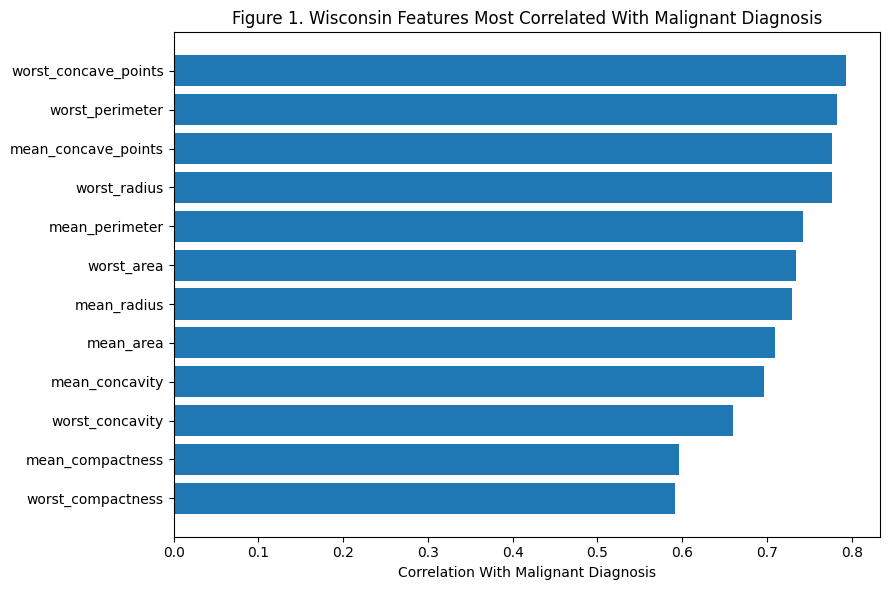

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [12]:
corr_with_target_w = wisconsin_df[wisconsin_features + [wisconsin_target]].corr()[wisconsin_target].drop(wisconsin_target)
top_corr_w = corr_with_target_w.abs().sort_values(ascending=False).head(12)
top_corr_w_signed = corr_with_target_w.loc[top_corr_w.index].sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr_w_signed.index, top_corr_w_signed.values)
plt.xlabel("Correlation With Malignant Diagnosis")
plt.title("Figure 1. Wisconsin Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": top_corr_w_signed.index,
    "correlation_with_malignant": top_corr_w_signed.values
})


#### Wisconsin EDA note

From earlier weeks, I expected tumor size and shape-related variables to matter. Gradient boosting should be useful because it can combine these features in nonlinear ways and capture interactions without me manually creating interaction terms.


#### Wisconsin train-test split

I use a stratified split so that benign and malignant cases stay in similar proportions in the training and testing sets.


In [13]:
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w,
    y_w,
    test_size=0.20,
    random_state=42,
    stratify=y_w
)

print("Training shape:", X_train_w.shape)
print("Testing shape:", X_test_w.shape)

print("\nTraining target distribution:")
print(y_train_w.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_w.value_counts(normalize=True).round(3))


Training shape: (455, 30)
Testing shape: (114, 30)

Training target distribution:
diagnosis_malignant
0    0.626
1    0.374
Name: proportion, dtype: float64

Testing target distribution:
diagnosis_malignant
0    0.632
1    0.368
Name: proportion, dtype: float64


#### Wisconsin baseline gradient boosting model

I start with a baseline gradient boosting classifier. This gives me a simple comparison point before tuning the learning rate, number of estimators, tree depth, and regularization settings.


In [14]:
wisconsin_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

w_gb_base_results, w_gb_base_train_pred, w_gb_base_test_pred, w_gb_base_train_prob, w_gb_base_test_prob = evaluate_classifier(
    "Wisconsin Baseline Gradient Boosting",
    wisconsin_gb_baseline,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_gb_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.994709


#### Baseline model note

If the training accuracy is much higher than the testing accuracy, that may suggest overfitting. Gradient boosting can overfit if the trees become too complex or if too many trees are added.


#### Wisconsin learning rate and number of estimators

The learning rate controls how much each new tree contributes to the model.

- Smaller learning rate: slower learning, usually needs more trees
- Larger learning rate: faster learning, but may overfit faster

The number of estimators controls how many trees are added.

I test several learning rate and estimator combinations to see the tradeoff.


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

w_lr_rows = []

for learning_rate in [0.01, 0.05, 0.10, 0.20]:
    for n_estimators in [50, 100, 200, 300]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42
        )

        recall_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="roc_auc")

        w_lr_rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

w_lr_results_df = pd.DataFrame(w_lr_rows).sort_values(["CV_recall_mean", "CV_roc_auc_mean"], ascending=[False, False])
w_lr_results_df.head(10)


,learning_rate,n_estimators,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
10,0.10,200,0.958824,0.014409,0.993189,0.005366
13,0.20,100,0.952941,0.014409,0.992570,0.005668
7,0.05,300,0.952941,0.014409,0.992157,0.005346
14,0.20,200,0.947059,0.022010,0.993602,0.005447
15,0.20,300,0.947059,0.022010,0.993602,0.006084
11,0.10,300,0.947059,0.022010,0.993498,0.005437
12,0.20,50,0.947059,0.022010,0.990506,0.005705
6,0.05,200,0.941176,0.026307,0.991331,0.005532
9,0.10,100,0.941176,0.026307,0.990918,0.006014
5,0.05,100,0.935294,0.034300,0.989577,0.005832


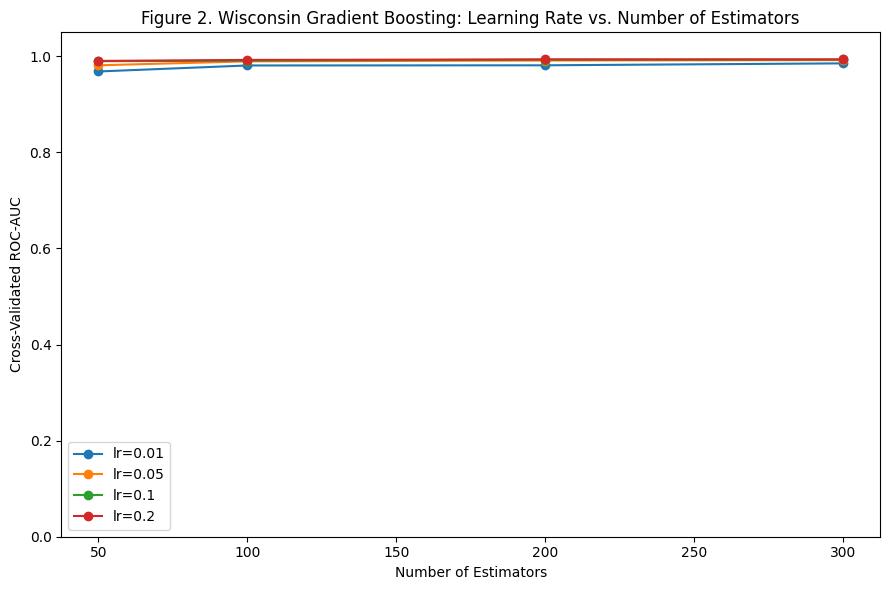

In [16]:
# Figure 2: Wisconsin learning rate and number of estimators
plt.figure(figsize=(9, 6))

for learning_rate in sorted(w_lr_results_df["learning_rate"].unique()):
    plot_df = w_lr_results_df[w_lr_results_df["learning_rate"] == learning_rate].sort_values("n_estimators")
    plt.plot(plot_df["n_estimators"], plot_df["CV_roc_auc_mean"], marker="o", label=f"lr={learning_rate}")

plt.xlabel("Number of Estimators")
plt.ylabel("Cross-Validated ROC-AUC")
plt.title("Figure 2. Wisconsin Gradient Boosting: Learning Rate vs. Number of Estimators")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


#### Wisconsin tree depth comparison

Tree depth controls how complex each individual tree can become.

- Shallow trees are more regularized and less likely to overfit.
- Deeper trees can capture more interactions but may overfit.

Gradient boosting often works well with shallow trees because the model builds many simple trees in sequence.


In [17]:
w_depth_rows = []

for max_depth in [1, 2, 3, 4, 5]:
    model = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=max_depth,
        random_state=42
    )

    recall_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X_train_w, y_train_w, cv=cv, scoring="roc_auc")

    w_depth_rows.append({
        "max_depth": max_depth,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std()
    })

w_depth_results_df = pd.DataFrame(w_depth_rows).sort_values("CV_roc_auc_mean", ascending=False)
w_depth_results_df


,max_depth,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,2,0.941176,0.026307,0.991331,0.005532
2,3,0.947059,0.034300,0.990712,0.006336
0,1,0.929412,0.044019,0.990093,0.007278
3,4,0.923529,0.054551,0.983901,0.010552
4,5,0.923529,0.057635,0.955366,0.046820


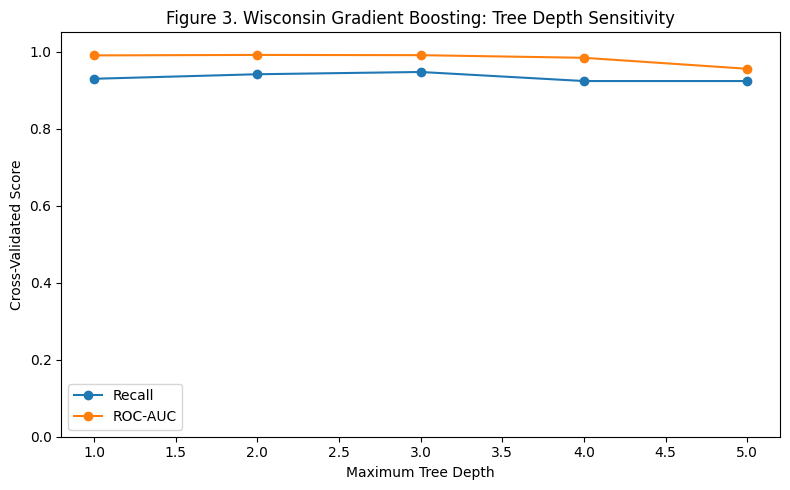

In [18]:
# Figure 3: Wisconsin tree depth comparison
plot_df = w_depth_results_df.sort_values("max_depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["max_depth"], plot_df["CV_recall_mean"], marker="o", label="Recall")
plt.plot(plot_df["max_depth"], plot_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Cross-Validated Score")
plt.title("Figure 3. Wisconsin Gradient Boosting: Tree Depth Sensitivity")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


#### Wisconsin tuned gradient boosting model

Now I tune several gradient boosting hyperparameters together.

I tune:

- `learning_rate`: how much each tree contributes
- `n_estimators`: number of trees
- `max_depth`: tree complexity
- `min_samples_leaf`: minimum samples in each leaf
- `subsample`: fraction of samples used for each tree

`subsample` below 1.0 adds randomness and can act like regularization because each tree is trained on only part of the data.


In [19]:
gb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.10],
    "n_estimators": [100, 200, 300],
    "max_depth": [1, 2, 3],
    "min_samples_leaf": [1, 3, 5],
    "subsample": [0.8, 1.0]
}

wisconsin_gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=1
)

wisconsin_gb_grid.fit(X_train_w, y_train_w)

print("Best Wisconsin gradient boosting parameters:")
print(wisconsin_gb_grid.best_params_)
print("\nBest cross-validated recall:", wisconsin_gb_grid.best_score_)

w_gb_tuned_results, w_gb_tuned_train_pred, w_gb_tuned_test_pred, w_gb_tuned_train_prob, w_gb_tuned_test_prob = evaluate_classifier(
    "Wisconsin Tuned Gradient Boosting",
    wisconsin_gb_grid.best_estimator_,
    X_train_w,
    X_test_w,
    y_train_w,
    y_test_w
)

pd.DataFrame([w_gb_base_results, w_gb_tuned_results])


Best Wisconsin gradient boosting parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 1.0}

Best cross-validated recall: 0.9647058823529411


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.994709
1,Wisconsin Tuned Gradient Boosting,1.0,0.964912,1.0,0.904762,0.95,0.995370


#### Wisconsin model evaluation

I evaluate the tuned Wisconsin gradient boosting model using a classification report, confusion matrix, and ROC curve.


Wisconsin tuned gradient boosting classification report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



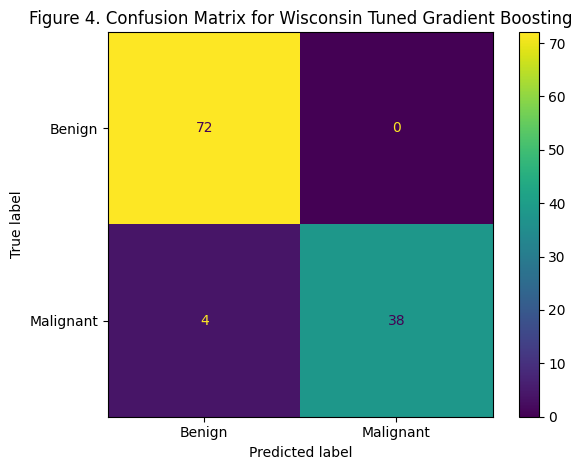

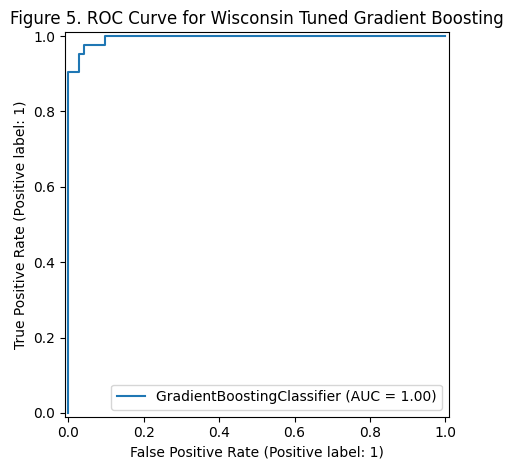

In [20]:
print("Wisconsin tuned gradient boosting classification report:")
print(classification_report(y_test_w, w_gb_tuned_test_pred, target_names=["Benign", "Malignant"]))

cm_w = confusion_matrix(y_test_w, w_gb_tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_w,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Figure 4. Confusion Matrix for Wisconsin Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(wisconsin_gb_grid.best_estimator_, X_test_w, y_test_w)
plt.title("Figure 5. ROC Curve for Wisconsin Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


#### Wisconsin feature importance

Gradient boosting provides feature importance scores. These show which tumor measurements were most useful in the boosted tree model.


In [21]:
w_gb_feature_importance = pd.DataFrame({
    "feature": wisconsin_features,
    "importance": wisconsin_gb_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

w_gb_feature_importance.head(15)


,feature,importance
22,worst_perimeter,0.509790
7,mean_concave_points,0.161250
27,worst_concave_points,0.090442
20,worst_radius,0.063799
21,worst_texture,0.031344
23,worst_area,0.030426
1,mean_texture,0.029962
26,worst_concavity,0.019804
3,mean_area,0.014064
13,area_error,0.013311


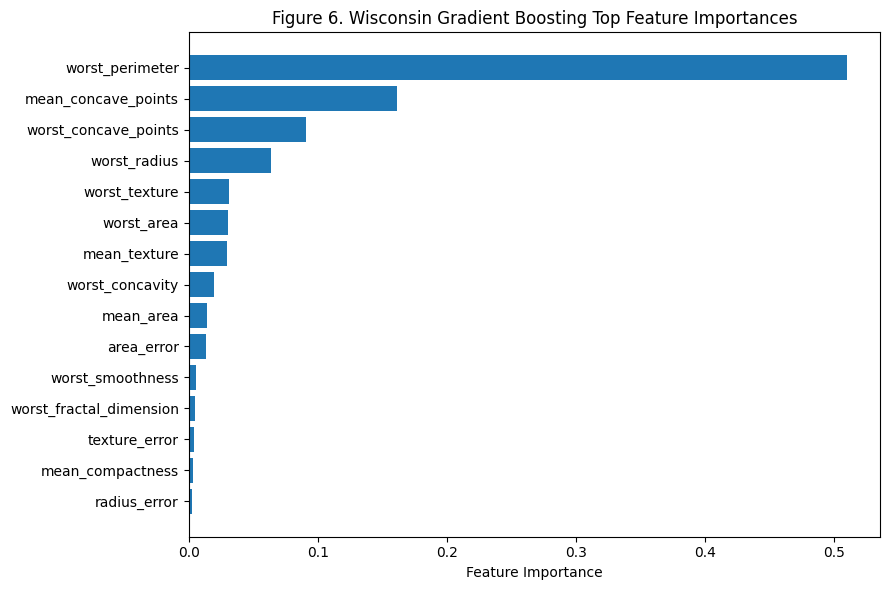

In [22]:
# Figure 6: Wisconsin gradient boosting feature importance
plot_df = w_gb_feature_importance.head(15).sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 6. Wisconsin Gradient Boosting Top Feature Importances")
plt.tight_layout()
plt.show()


#### Wisconsin gradient boosting interpretation

For the Wisconsin dataset, I expected gradient boosting to perform well because the dataset has strong tumor morphology features. The model can combine size, shape, and texture features in a nonlinear way.

If the top features are related to radius, area, perimeter, concavity, or worst-case measurements, that supports my earlier conclusion that tumor size and shape are major signals for diagnosis.


### Part B — Coimbra (clinical & blood biomarkers)

#### Load and prepare Coimbra dataset

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with the rest of my project, I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls


#### Coimbra features and target

The Coimbra dataset has 9 predictors. These are clinical and blood-based biomarkers rather than tumor image measurements.


In [23]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_c = coimbra_df[coimbra_features]
y_c = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of Coimbra rows:", X_c.shape[0])
print("Number of Coimbra features:", X_c.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of Coimbra rows: 116
Number of Coimbra features: 9


#### Coimbra EDA before gradient boosting

Before modeling, I check how the biomarkers differ between patients and healthy controls.


In [24]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


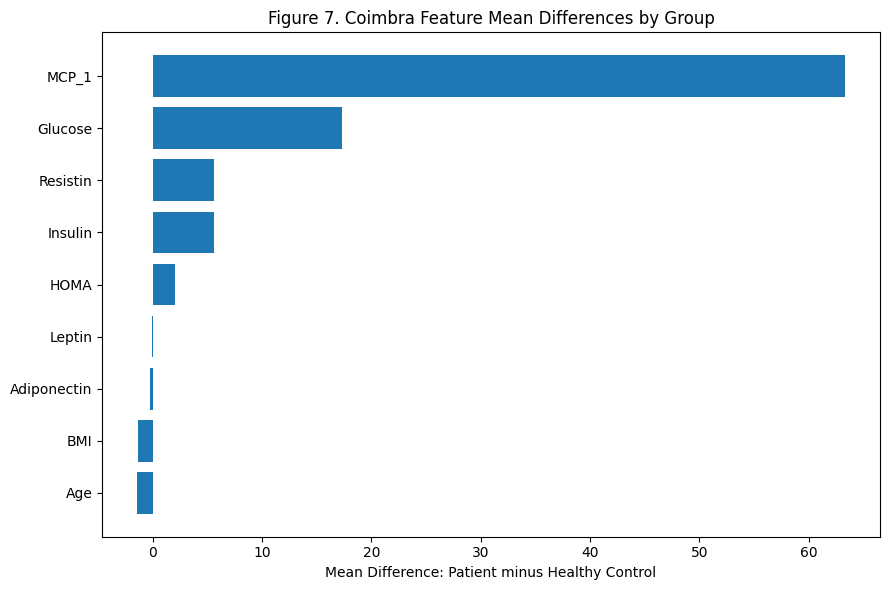

In [25]:
# Figure 7: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure 7. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


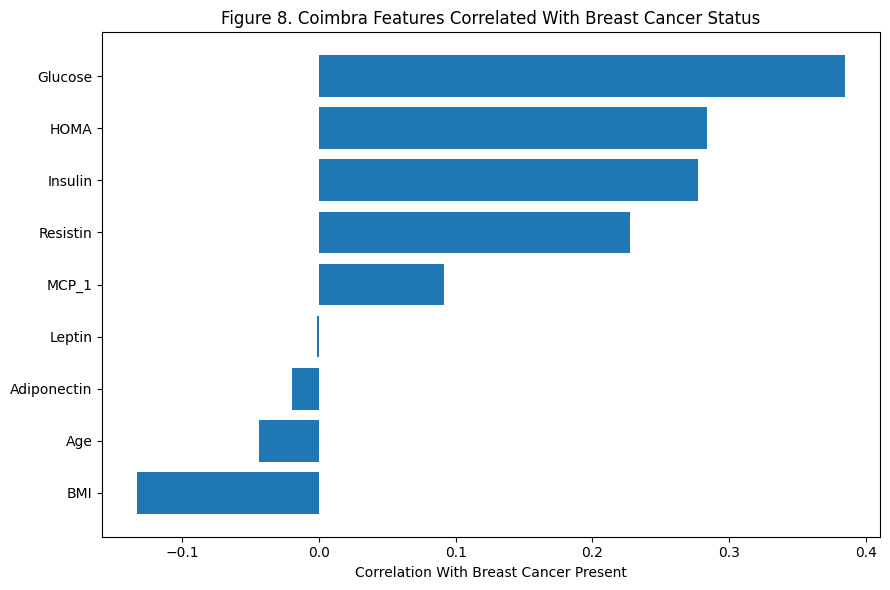

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [26]:
# Figure 8: Coimbra correlations with breast cancer status
corr_with_target_c = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
corr_with_target_c_sorted = corr_with_target_c.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(corr_with_target_c_sorted.index, corr_with_target_c_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure 8. Coimbra Features Correlated With Breast Cancer Status")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": corr_with_target_c_sorted.index,
    "correlation_with_breast_cancer_present": corr_with_target_c_sorted.values
})


#### Coimbra EDA note

The Coimbra predictors are more indirect than the Wisconsin tumor measurements. Because of this, I expect prediction to be harder and less stable. Gradient boosting may still help because it can model nonlinear relationships among biomarkers.


#### Coimbra train-test split

I use a stratified split so the training and testing sets keep similar proportions of patients and healthy controls.


In [27]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size=0.20,
    random_state=42,
    stratify=y_c
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


#### Coimbra baseline gradient boosting model

I start with a baseline gradient boosting model for Coimbra.


In [28]:
coimbra_gb_baseline = GradientBoostingClassifier(
    random_state=42
)

c_gb_base_results, c_gb_base_train_pred, c_gb_base_test_pred, c_gb_base_train_prob, c_gb_base_test_prob = evaluate_classifier(
    "Coimbra Baseline Gradient Boosting",
    coimbra_gb_baseline,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_gb_base_results])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119


#### Coimbra learning rate and number of estimators

Since Coimbra is small, I expect the learning rate and number of estimators to matter a lot. Too many trees or too high of a learning rate may overfit.


In [29]:
c_lr_rows = []

for learning_rate in [0.01, 0.05, 0.10, 0.20]:
    for n_estimators in [50, 100, 200, 300]:
        model = GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=2,
            random_state=42
        )

        recall_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="recall")
        auc_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="roc_auc")

        c_lr_rows.append({
            "learning_rate": learning_rate,
            "n_estimators": n_estimators,
            "CV_recall_mean": recall_scores.mean(),
            "CV_recall_std": recall_scores.std(),
            "CV_roc_auc_mean": auc_scores.mean(),
            "CV_roc_auc_std": auc_scores.std()
        })

c_lr_results_df = pd.DataFrame(c_lr_rows).sort_values(["CV_recall_mean", "CV_roc_auc_mean"], ascending=[False, False])
c_lr_results_df.head(10)


,learning_rate,n_estimators,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
1,0.01,100,0.741818,0.137822,0.739987,0.079229
4,0.05,50,0.723636,0.173881,0.773321,0.100441
12,0.20,50,0.723636,0.161971,0.755126,0.097857
6,0.05,200,0.723636,0.161971,0.743687,0.093357
7,0.05,300,0.721818,0.215099,0.743687,0.093357
5,0.05,100,0.705455,0.155303,0.748308,0.100460
8,0.10,50,0.705455,0.155303,0.745429,0.109983
15,0.20,300,0.705455,0.110086,0.729091,0.081630
2,0.01,200,0.703636,0.157417,0.770316,0.113371
3,0.01,300,0.703636,0.157417,0.769343,0.112646


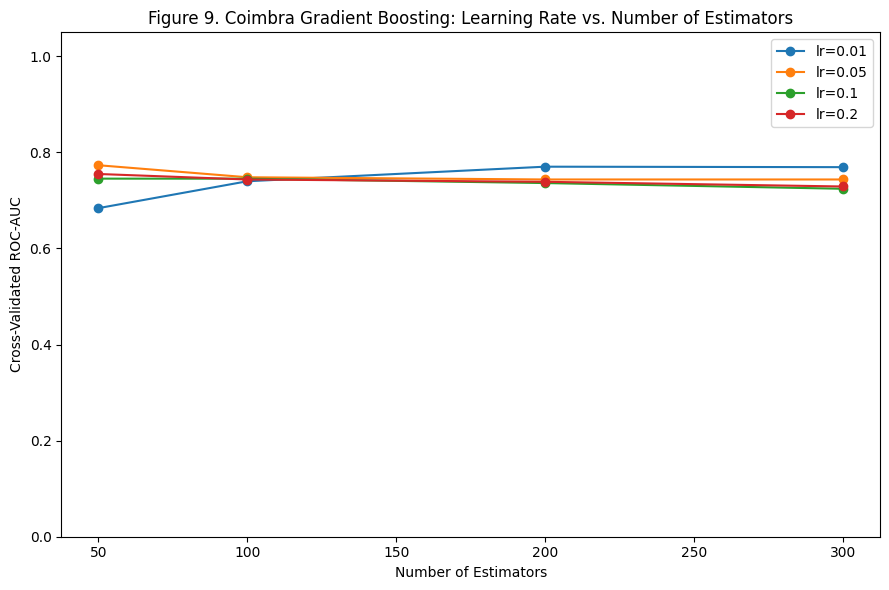

In [30]:
# Figure 9: Coimbra learning rate and number of estimators
plt.figure(figsize=(9, 6))

for learning_rate in sorted(c_lr_results_df["learning_rate"].unique()):
    plot_df = c_lr_results_df[c_lr_results_df["learning_rate"] == learning_rate].sort_values("n_estimators")
    plt.plot(plot_df["n_estimators"], plot_df["CV_roc_auc_mean"], marker="o", label=f"lr={learning_rate}")

plt.xlabel("Number of Estimators")
plt.ylabel("Cross-Validated ROC-AUC")
plt.title("Figure 9. Coimbra Gradient Boosting: Learning Rate vs. Number of Estimators")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


#### Coimbra tree depth comparison

For Coimbra, I expect shallow trees to be safer because the dataset is small. Deep trees may overfit to a few observations.


In [31]:
c_depth_rows = []

for max_depth in [1, 2, 3, 4, 5]:
    model = GradientBoostingClassifier(
        learning_rate=0.05,
        n_estimators=200,
        max_depth=max_depth,
        random_state=42
    )

    recall_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X_train_c, y_train_c, cv=cv, scoring="roc_auc")

    c_depth_rows.append({
        "max_depth": max_depth,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std()
    })

c_depth_results_df = pd.DataFrame(c_depth_rows).sort_values("CV_roc_auc_mean", ascending=False)
c_depth_results_df


,max_depth,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std
3,4,0.801818,0.091525,0.753043,0.115401
4,5,0.823636,0.074212,0.747778,0.089446
2,3,0.721818,0.195621,0.745354,0.089301
1,2,0.723636,0.161971,0.743687,0.093357
0,1,0.685455,0.148112,0.724684,0.108992


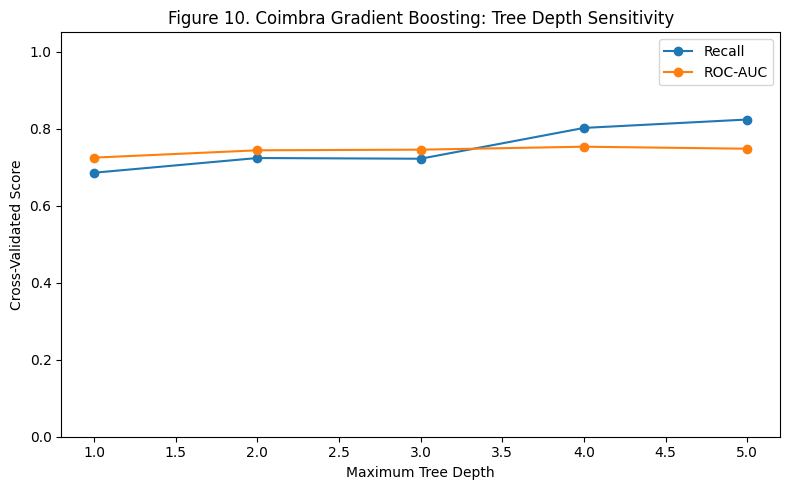

In [32]:
# Figure 10: Coimbra tree depth comparison
plot_df = c_depth_results_df.sort_values("max_depth")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["max_depth"], plot_df["CV_recall_mean"], marker="o", label="Recall")
plt.plot(plot_df["max_depth"], plot_df["CV_roc_auc_mean"], marker="o", label="ROC-AUC")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Cross-Validated Score")
plt.title("Figure 10. Coimbra Gradient Boosting: Tree Depth Sensitivity")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


#### Coimbra tuned gradient boosting model

Now I tune the same main gradient boosting hyperparameters for Coimbra. Because this dataset is small, I pay close attention to regularization settings like `max_depth`, `min_samples_leaf`, and `subsample`.


In [33]:
coimbra_gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=1
)

coimbra_gb_grid.fit(X_train_c, y_train_c)

print("Best Coimbra gradient boosting parameters:")
print(coimbra_gb_grid.best_params_)
print("\nBest cross-validated recall:", coimbra_gb_grid.best_score_)

c_gb_tuned_results, c_gb_tuned_train_pred, c_gb_tuned_test_pred, c_gb_tuned_train_prob, c_gb_tuned_test_prob = evaluate_classifier(
    "Coimbra Tuned Gradient Boosting",
    coimbra_gb_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([c_gb_base_results, c_gb_tuned_results])


Best Coimbra gradient boosting parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 1.0}

Best cross-validated recall: 0.82


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc
0,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119
1,Coimbra Tuned Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.874126


#### Coimbra model evaluation

I evaluate the tuned Coimbra gradient boosting model using a classification report, confusion matrix, and ROC curve.


Coimbra tuned gradient boosting classification report:
                 precision    recall  f1-score   support

Healthy Control       0.82      0.82      0.82        11
        Patient       0.85      0.85      0.85        13

       accuracy                           0.83        24
      macro avg       0.83      0.83      0.83        24
   weighted avg       0.83      0.83      0.83        24



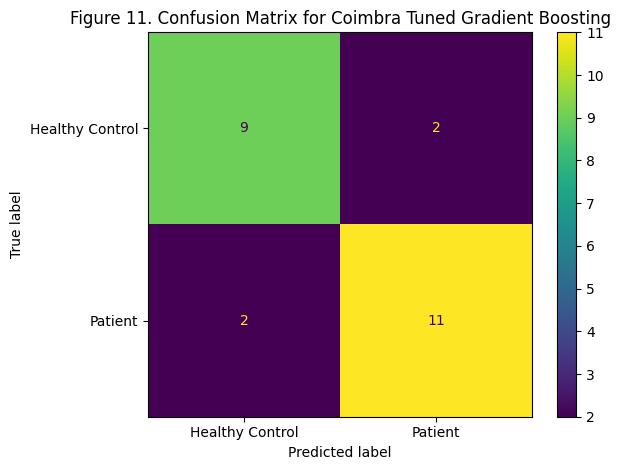

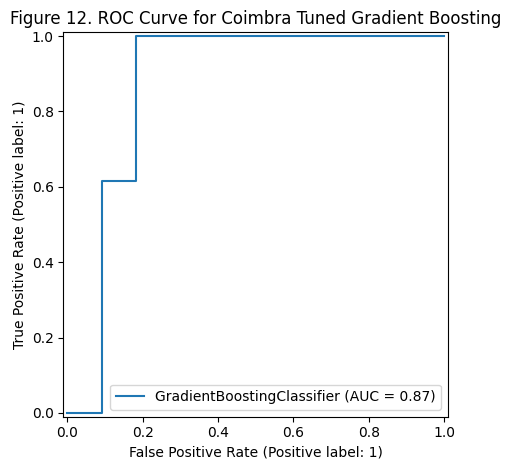

In [34]:
print("Coimbra tuned gradient boosting classification report:")
print(classification_report(y_test_c, c_gb_tuned_test_pred, target_names=["Healthy Control", "Patient"]))

cm_c = confusion_matrix(y_test_c, c_gb_tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["Healthy Control", "Patient"]
)

disp.plot()
plt.title("Figure 11. Confusion Matrix for Coimbra Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_estimator(coimbra_gb_grid.best_estimator_, X_test_c, y_test_c)
plt.title("Figure 12. ROC Curve for Coimbra Tuned Gradient Boosting")
plt.tight_layout()
plt.show()


#### Coimbra feature importance

I use feature importance to see which clinical biomarkers were most useful in the boosted tree model.


In [35]:
c_gb_feature_importance = pd.DataFrame({
    "feature": coimbra_features,
    "importance": coimbra_gb_grid.best_estimator_.feature_importances_
}).sort_values("importance", ascending=False)

c_gb_feature_importance


,feature,importance
2,Glucose,0.330695
1,BMI,0.217956
7,Resistin,0.150324
0,Age,0.097080
5,Leptin,0.050135
8,MCP_1,0.049969
4,HOMA,0.036681
6,Adiponectin,0.033798
3,Insulin,0.033362


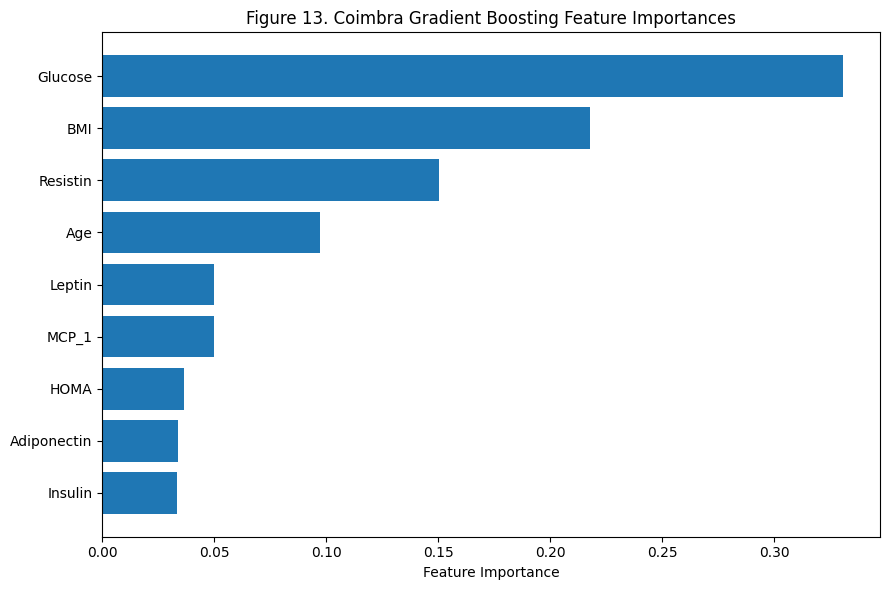

In [36]:
# Figure 13: Coimbra gradient boosting feature importance
plot_df = c_gb_feature_importance.sort_values("importance")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Feature Importance")
plt.title("Figure 13. Coimbra Gradient Boosting Feature Importances")
plt.tight_layout()
plt.show()


#### Coimbra gradient boosting interpretation

For Coimbra, I expected gradient boosting to be more sensitive to overfitting because the dataset is smaller. The model may still be useful because it can capture nonlinear relationships among biomarkers.

Feature importance helps connect the model back to the healthcare context by showing which clinical or blood-based variables contributed most to prediction.


### Part C — Comparison across both datasets

#### Compare Wisconsin and Coimbra gradient boosting results

Now I compare the baseline and tuned gradient boosting models across both datasets.


In [37]:
wisconsin_gb_results_df = pd.DataFrame([
    w_gb_base_results,
    w_gb_tuned_results
])
wisconsin_gb_results_df["dataset"] = "Wisconsin"

coimbra_gb_results_df = pd.DataFrame([
    c_gb_base_results,
    c_gb_tuned_results
])
coimbra_gb_results_df["dataset"] = "Coimbra"

week9_combined_results = pd.concat(
    [wisconsin_gb_results_df, coimbra_gb_results_df],
    ignore_index=True
)

week9_combined_results.sort_values(["test_recall_positive", "test_roc_auc"], ascending=[False, False])


,model,train_accuracy,test_accuracy,test_precision_positive,test_recall_positive,test_f1_positive,test_roc_auc,dataset
1,Wisconsin Tuned Gradient Boosting,1.0,0.964912,1.000000,0.904762,0.950000,0.995370,Wisconsin
0,Wisconsin Baseline Gradient Boosting,1.0,0.964912,1.000000,0.904762,0.950000,0.994709,Wisconsin
2,Coimbra Baseline Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.881119,Coimbra
3,Coimbra Tuned Gradient Boosting,1.0,0.833333,0.846154,0.846154,0.846154,0.874126,Coimbra


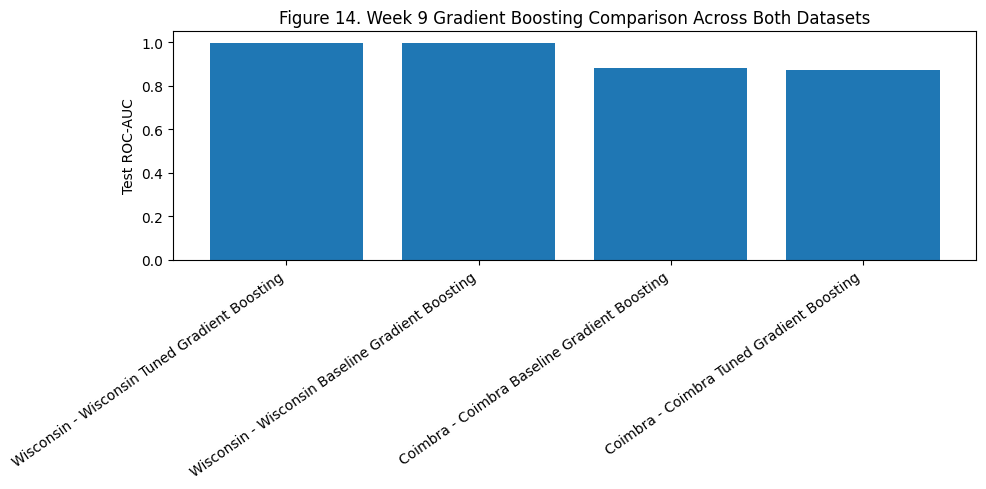

In [38]:
# Figure 14: Combined gradient boosting comparison
plot_df = week9_combined_results.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["dataset"] + " - " + plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure 14. Week 9 Gradient Boosting Comparison Across Both Datasets")
plt.ylim(0, 1.05)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


#### Regularization comparison

In this notebook, I treated regularization as more than one setting. For gradient boosting, regularization came from:

- Lower learning rate
- Limiting tree depth
- Increasing `min_samples_leaf`
- Using `subsample` below 1.0
- Using cross-validation to avoid choosing a model that only works on one split

This matters because boosted trees can become very powerful and can overfit if they are allowed to become too complex.


#### Week 9 summary

This cell prints a short summary using the actual notebook results.


In [39]:
best_w_gb = wisconsin_gb_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

best_c_gb = coimbra_gb_results_df.sort_values(
    ["test_recall_positive", "test_roc_auc"],
    ascending=[False, False]
).iloc[0]

print("Week 9 Gradient Boosting Summary")


print("Best Wisconsin gradient boosting model:")
print(best_w_gb["model"])
print(f"Test accuracy: {best_w_gb['test_accuracy']:.4f}")
print(f"Test recall for malignant cases: {best_w_gb['test_recall_positive']:.4f}")
print(f"Test precision for malignant cases: {best_w_gb['test_precision_positive']:.4f}")
print(f"Test F1: {best_w_gb['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_w_gb['test_roc_auc']:.4f}")

print("\nBest Coimbra gradient boosting model:")
print(best_c_gb["model"])
print(f"Test accuracy: {best_c_gb['test_accuracy']:.4f}")
print(f"Test recall for patients: {best_c_gb['test_recall_positive']:.4f}")
print(f"Test precision for patients: {best_c_gb['test_precision_positive']:.4f}")
print(f"Test F1: {best_c_gb['test_f1_positive']:.4f}")
print(f"Test ROC-AUC: {best_c_gb['test_roc_auc']:.4f}")

print("\nBest Wisconsin gradient boosting hyperparameters:")
print(wisconsin_gb_grid.best_params_)

print("\nBest Coimbra gradient boosting hyperparameters:")
print(coimbra_gb_grid.best_params_)

print("\nTop 5 Wisconsin feature importances:")
for feature in w_gb_feature_importance.head(5)["feature"]:
    print("-", feature)

print("\nTop 5 Coimbra feature importances:")
for feature in c_gb_feature_importance.head(5)["feature"]:
    print("-", feature)


Week 9 Gradient Boosting Summary
Best Wisconsin gradient boosting model:
Wisconsin Tuned Gradient Boosting
Test accuracy: 0.9649
Test recall for malignant cases: 0.9048
Test precision for malignant cases: 1.0000
Test F1: 0.9500
Test ROC-AUC: 0.9954

Best Coimbra gradient boosting model:
Coimbra Baseline Gradient Boosting
Test accuracy: 0.8333
Test recall for patients: 0.8462
Test precision for patients: 0.8462
Test F1: 0.8462
Test ROC-AUC: 0.8811

Best Wisconsin gradient boosting hyperparameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 200, 'subsample': 1.0}

Best Coimbra gradient boosting hyperparameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 100, 'subsample': 1.0}

Top 5 Wisconsin feature importances:
- worst_perimeter
- mean_concave_points
- worst_concave_points
- worst_radius
- worst_texture

Top 5 Coimbra feature importances:
- Glucose
- BMI
- Resistin
- Age
- Leptin


#### Week 9 findings and interpretation

After running this Week 9 notebook, I learned that gradient boosting is a strong modeling technique because it builds a sequence of trees that correct earlier mistakes. This makes it more flexible than a single decision tree.

For the **Wisconsin dataset**, I expected gradient boosting to perform well because the tumor measurements directly describe the tumor. The model can use combinations of radius, area, concavity, and other shape features to classify malignant and benign tumors.

For the **Coimbra dataset**, I expected the model to be less stable because the dataset is smaller and the predictors are indirect clinical biomarkers. Gradient boosting can still be useful, but it needs more careful regularization.

The most important hyperparameters were learning rate, number of estimators, and tree depth. A lower learning rate makes the model learn more slowly, usually requiring more trees. More estimators can improve performance, but too many trees may overfit. Tree depth controls how complex each tree can become. Shallow trees are usually safer because each tree only captures a simple pattern.

Regularization was important in both datasets. I used smaller learning rates, limited tree depth, minimum leaf size, subsampling, and cross-validation. These techniques helped reduce the risk that the model would memorize the training data.

Overall, gradient boosting gave me another way to compare image-based tumor features with clinical biomarker data. It also helped me see how tuning and regularization can affect a powerful ensemble model.


#### Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is likely better suited for gradient boosting because it has more rows and direct tumor morphology features. The Coimbra dataset is still useful, but it asks a different question: can routine clinical and blood-based biomarkers help identify breast cancer status?

This comparison is helpful for my capstone because it shows that model performance depends not only on the algorithm, but also on the type and quality of the data. Tumor image features appear more directly related to diagnosis, while clinical biomarkers may provide useful but less direct information.


## 4. Week 10 — Clustering 1: K-Means

**Week topic:** K-means clustering, elbow method, silhouette score, feature scaling, and distance metrics

#### Notebook purpose

For Week 10, I am applying **K-means clustering** to both capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers.

K-means is different from the supervised models used in earlier weeks because it does **not** use the diagnosis label when creating clusters. After clustering, I compare the clusters to the known diagnosis labels only for interpretation.

The main goal is to see whether the data naturally groups itself in a way that resembles the known cancer/non-cancer outcome.

#### Helper functions

These helper functions are used for both datasets.

Important note: standard K-means is based on Euclidean distance because it minimizes within-cluster squared distances. I still compare distance metrics by calculating silhouette scores using Euclidean, Manhattan, and cosine distances after the clusters are created.


In [40]:
def scale_data(X, method):
    if method == "none":
        return pd.DataFrame(X.copy(), columns=X.columns, index=X.index)
    elif method == "standard":
        scaler = StandardScaler()
    elif method == "minmax":
        scaler = MinMaxScaler()
    else:
        raise ValueError("Use method='none', 'standard', or 'minmax'.")

    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index)


def run_kmeans(X_scaled, k):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    return model, labels


def elbow_and_silhouette(X_scaled, k_values):
    rows = []
    for k in k_values:
        model, labels = run_kmeans(X_scaled, k)
        rows.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean")
        })
    return pd.DataFrame(rows)


def compare_distance_metrics(X_scaled, labels):
    rows = []
    for metric in ["euclidean", "manhattan", "cosine"]:
        rows.append({
            "distance_metric": metric,
            "silhouette_score": silhouette_score(X_scaled, labels, metric=metric)
        })
    return pd.DataFrame(rows).sort_values("silhouette_score", ascending=False)


def compare_clusters_to_labels(labels, y_true, dataset_name):
    return {
        "dataset": dataset_name,
        "adjusted_rand_index": adjusted_rand_score(y_true, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_true, labels)
    }


def plot_pca_view(X_scaled, labels, y_true, dataset_name, class_names):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)

    pca_df = pd.DataFrame({
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "cluster": labels,
        "true_label": y_true
    })

    plt.figure(figsize=(8, 6))
    for cluster in sorted(pca_df["cluster"].unique()):
        group = pca_df[pca_df["cluster"] == cluster]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=f"Cluster {cluster}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{dataset_name}: K-Means Clusters in PCA Space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    for value, label in class_names.items():
        group = pca_df[pca_df["true_label"] == value]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=label)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"{dataset_name}: Known Labels in PCA Space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pca_df


### Part A — Wisconsin (Diagnostic)

#### Load Wisconsin dataset

The sklearn target is originally coded as `0 = malignant` and `1 = benign`. I recode it so that `1 = malignant` and `0 = benign`.


#### Wisconsin features and target label

The diagnosis label is not used to form clusters. It is saved only so I can compare the unsupervised clusters back to the known diagnosis later.


In [41]:
wisconsin_features = [c for c in wisconsin_df.columns if c not in ["diagnosis_malignant", "diagnosis_label"]]

X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df["diagnosis_malignant"]

print("Wisconsin rows:", X_w.shape[0])
print("Wisconsin features:", X_w.shape[1])


Wisconsin rows: 569
Wisconsin features: 30


#### Wisconsin feature scaling check

K-means depends on distance, so features with larger numeric ranges can dominate the clustering if the data are not scaled.


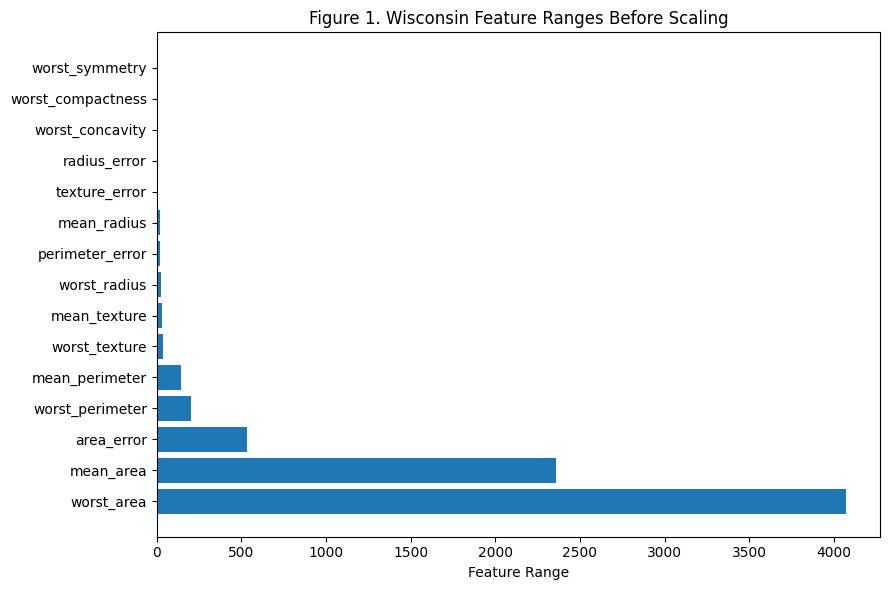

,min,max,mean,std,range
worst_area,185.20000,4254.0000,880.583128,569.356993,4068.80000
mean_area,143.50000,2501.0000,654.889104,351.914129,2357.50000
area_error,6.80200,542.2000,40.337079,45.491006,535.39800
worst_perimeter,50.41000,251.2000,107.261213,33.602542,200.79000
mean_perimeter,43.79000,188.5000,91.969033,24.298981,144.71000
worst_texture,12.02000,49.5400,25.677223,6.146258,37.52000
mean_texture,9.71000,39.2800,19.289649,4.301036,29.57000
worst_radius,7.93000,36.0400,16.269190,4.833242,28.11000
perimeter_error,0.75700,21.9800,2.866059,2.021855,21.22300
mean_radius,6.98100,28.1100,14.127292,3.524049,21.12900


In [42]:
w_scale = X_w.agg(["min", "max", "mean", "std"]).T
w_scale["range"] = w_scale["max"] - w_scale["min"]
w_scale = w_scale.sort_values("range", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(w_scale.index, w_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 1. Wisconsin Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

w_scale


#### Wisconsin scaling comparison with k = 2

Because the known outcome has two groups, I first compare K-means with `k = 2` using no scaling, standard scaling, and min-max scaling.


In [43]:
w_scaling_results = []

for method in ["none", "standard", "minmax"]:
    X_scaled = scale_data(X_w, method)
    model, labels = run_kmeans(X_scaled, k=2)
    w_scaling_results.append({
        "scaling": method,
        "inertia": model.inertia_,
        "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_w, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_w, labels)
    })

w_scaling_df = pd.DataFrame(w_scaling_results)
w_scaling_df.sort_values("silhouette_euclidean", ascending=False)


,scaling,inertia,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,none,7.794310e+07,0.697265,0.491425,0.464793
2,minmax,2.158383e+02,0.384549,0.730175,0.623086
1,standard,1.159546e+04,0.344974,0.670721,0.554612


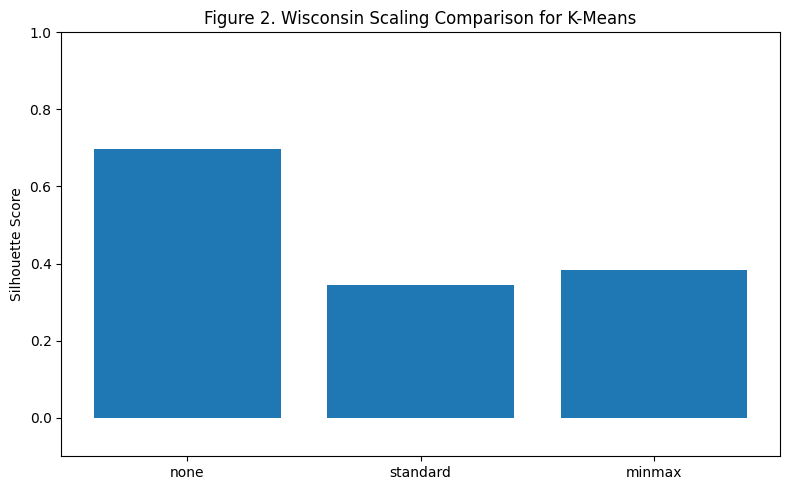

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(w_scaling_df["scaling"], w_scaling_df["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 2. Wisconsin Scaling Comparison for K-Means")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Wisconsin elbow method

I use the elbow method to examine inertia for different values of `k`. I look for where the curve begins to flatten.


In [45]:
X_w_standard = scale_data(X_w, "standard")
k_values = range(2, 11)

w_elbow_df = elbow_and_silhouette(X_w_standard, k_values)
w_elbow_df


,k,inertia,silhouette_euclidean
0,2,11595.461474,0.344974
1,3,10061.797818,0.314384
2,4,9257.362458,0.280336
3,5,8557.727454,0.158528
4,6,7970.263835,0.160367
5,7,7540.318697,0.153186
6,8,7192.191985,0.139234
7,9,6837.628936,0.147040
8,10,6603.404402,0.136656


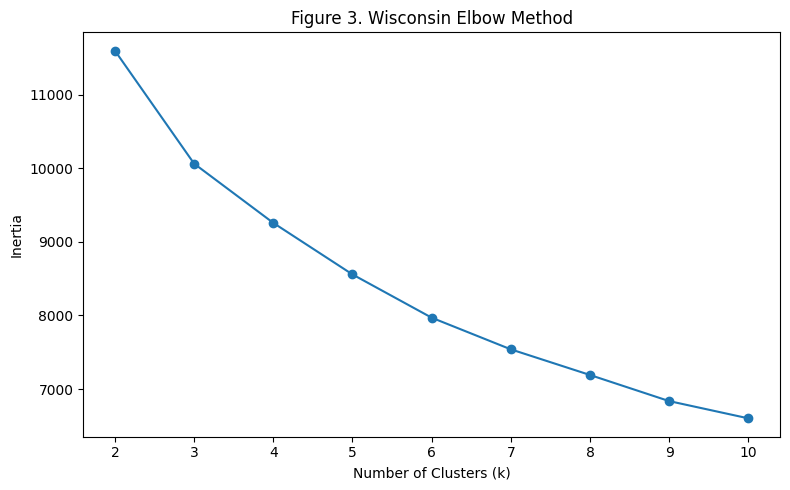

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(w_elbow_df["k"], w_elbow_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 3. Wisconsin Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


#### Wisconsin silhouette score

The silhouette score helps judge how separated the clusters are. Higher scores are better.


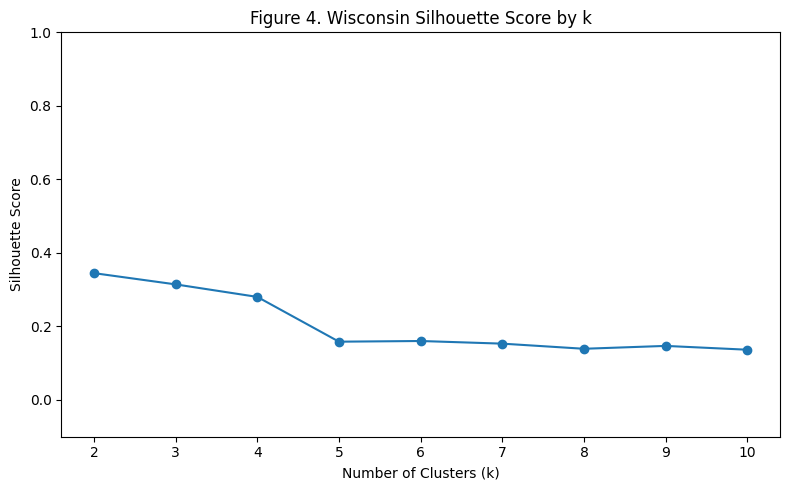

,k,inertia,silhouette_euclidean
0,2,11595.461474,0.344974
1,3,10061.797818,0.314384
2,4,9257.362458,0.280336
4,6,7970.263835,0.160367
3,5,8557.727454,0.158528
5,7,7540.318697,0.153186
7,9,6837.628936,0.147040
6,8,7192.191985,0.139234
8,10,6603.404402,0.136656


In [47]:
plt.figure(figsize=(8, 5))
plt.plot(w_elbow_df["k"], w_elbow_df["silhouette_euclidean"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 4. Wisconsin Silhouette Score by k")
plt.xticks(list(k_values))
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

w_elbow_df.sort_values("silhouette_euclidean", ascending=False)


#### Wisconsin final K-means model

I choose the `k` with the highest silhouette score. Then I compare the clusters to the known benign/malignant labels.


In [48]:
best_k_w = int(w_elbow_df.sort_values("silhouette_euclidean", ascending=False).iloc[0]["k"])
w_final_model, w_final_labels = run_kmeans(X_w_standard, best_k_w)

print("Best Wisconsin k based on silhouette:", best_k_w)

w_cluster_comparison = pd.crosstab(
    pd.Series(w_final_labels, name="cluster"),
    wisconsin_df["diagnosis_label"],
    margins=True
)

w_label_scores = compare_clusters_to_labels(w_final_labels, y_w, "Wisconsin")

display(w_cluster_comparison)
pd.DataFrame([w_label_scores])


Best Wisconsin k based on silhouette: 2


diagnosis_label,Benign,Malignant,All
cluster,,,
0,14,175,189
1,343,37,380
All,357,212,569


,dataset,adjusted_rand_index,normalized_mutual_info
0,Wisconsin,0.670721,0.554612


#### Wisconsin distance metrics

Standard K-means uses Euclidean distance, but I compare silhouette scores using Euclidean, Manhattan, and cosine distances for the final cluster labels.


In [49]:
w_distance_df = compare_distance_metrics(X_w_standard, w_final_labels)
w_distance_df


,distance_metric,silhouette_score
2,cosine,0.472550
1,manhattan,0.384686
0,euclidean,0.344974


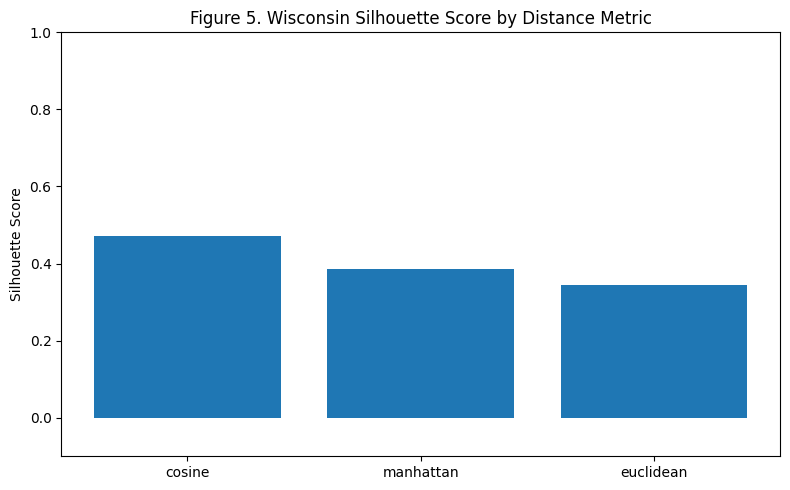

In [50]:
plt.figure(figsize=(8, 5))
plt.bar(w_distance_df["distance_metric"], w_distance_df["silhouette_score"])
plt.ylabel("Silhouette Score")
plt.title("Figure 5. Wisconsin Silhouette Score by Distance Metric")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Wisconsin PCA visualization

PCA is used only for visualization. The K-means model was fit using all scaled features.


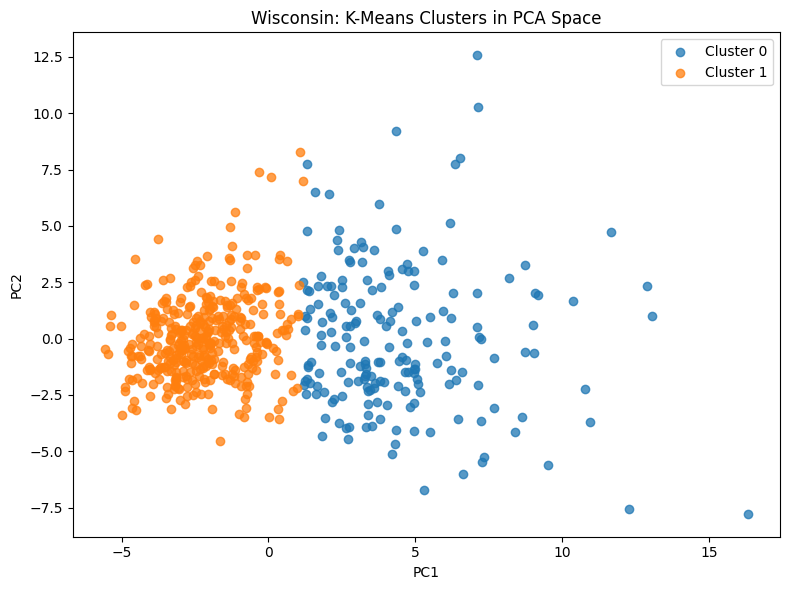

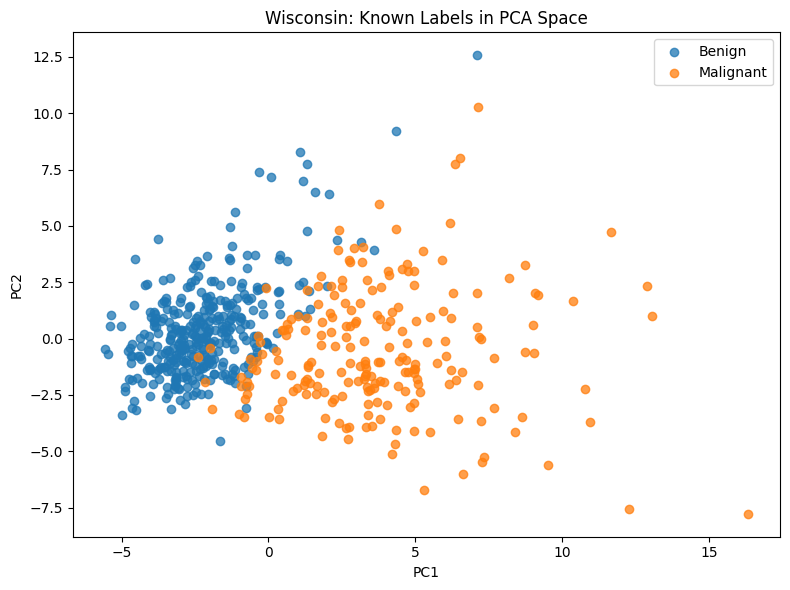

In [51]:
w_pca_df = plot_pca_view(
    X_w_standard,
    w_final_labels,
    y_w,
    "Wisconsin",
    {0: "Benign", 1: "Malignant"}
)


#### Wisconsin interpretation

For Wisconsin, I expected K-means clusters to align somewhat with diagnosis because the tumor measurements are directly related to malignancy. However, K-means is unsupervised, so it is not trying to predict diagnosis. It only groups observations based on feature similarity.

If the clusters overlap with benign and malignant labels, that suggests the tumor measurements have natural structure related to diagnosis.


### Part B — Coimbra (clinical & blood biomarkers)

#### Load Coimbra dataset

The Coimbra dataset target is `Classification`, where:

- `1 = Healthy controls`
- `2 = Breast cancer patients`

I recode it so that `1 = breast cancer patient` and `0 = healthy control`.


#### Coimbra features and target label

The target label is only used after clustering to interpret whether the clusters resemble patient/control groups.


In [52]:
coimbra_features = [c for c in coimbra_df.columns if c not in ["Classification", "breast_cancer_present", "diagnosis_group"]]

X_c = coimbra_df[coimbra_features]
y_c = coimbra_df["breast_cancer_present"]

print("Coimbra rows:", X_c.shape[0])
print("Coimbra features:", X_c.shape[1])
print(coimbra_features)


Coimbra rows: 116
Coimbra features: 9
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']


#### Coimbra feature scaling check

Coimbra features are clinical and blood-based biomarkers, and they are measured on very different scales.


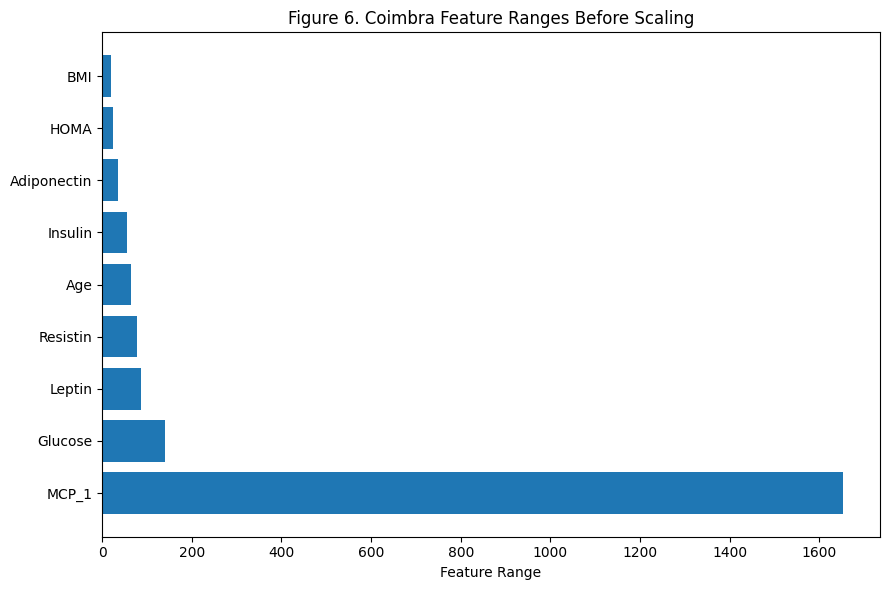

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759


In [53]:
c_scale = X_c.agg(["min", "max", "mean", "std"]).T
c_scale["range"] = c_scale["max"] - c_scale["min"]
c_scale = c_scale.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(c_scale.index, c_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 6. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

c_scale


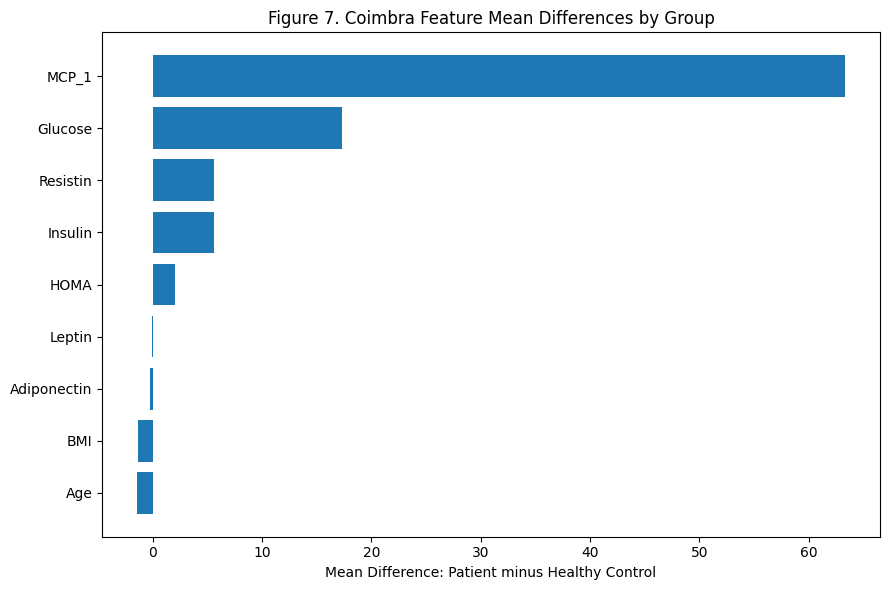

diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


In [54]:
c_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
c_group_means["difference_patient_minus_control"] = c_group_means["Patient"] - c_group_means["Healthy Control"]

plot_df = c_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure 7. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()

c_group_means.sort_values("difference_patient_minus_control")


#### Coimbra scaling comparison with k = 2

I compare no scaling, standard scaling, and min-max scaling with `k = 2`.


In [55]:
c_scaling_results = []

for method in ["none", "standard", "minmax"]:
    X_scaled = scale_data(X_c, method)
    model, labels = run_kmeans(X_scaled, k=2)
    c_scaling_results.append({
        "scaling": method,
        "inertia": model.inertia_,
        "silhouette_euclidean": silhouette_score(X_scaled, labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_c, labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_c, labels)
    })

c_scaling_df = pd.DataFrame(c_scaling_results)
c_scaling_df.sort_values("silhouette_euclidean", ascending=False)


,scaling,inertia,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,none,5.522775e+06,0.573208,-0.008840,0.004384
1,standard,8.388271e+02,0.236727,0.001866,0.017052
2,minmax,3.212725e+01,0.203267,-0.008383,0.000104


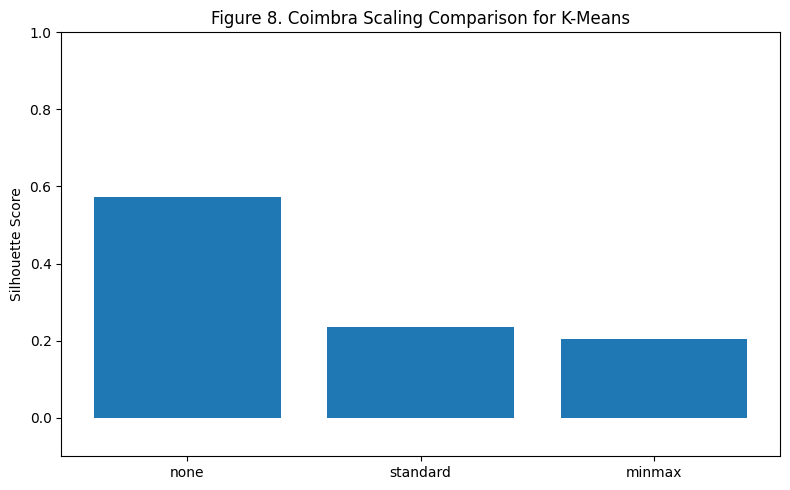

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(c_scaling_df["scaling"], c_scaling_df["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 8. Coimbra Scaling Comparison for K-Means")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Coimbra elbow method

In [57]:
X_c_standard = scale_data(X_c, "standard")

c_elbow_df = elbow_and_silhouette(X_c_standard, k_values)
c_elbow_df


,k,inertia,silhouette_euclidean
0,2,838.827100,0.236727
1,3,698.234576,0.177388
2,4,612.520239,0.173927
3,5,544.464780,0.185935
4,6,494.378624,0.182839
5,7,450.851846,0.194602
6,8,418.302944,0.155148
7,9,382.302260,0.170985
8,10,358.597163,0.174461


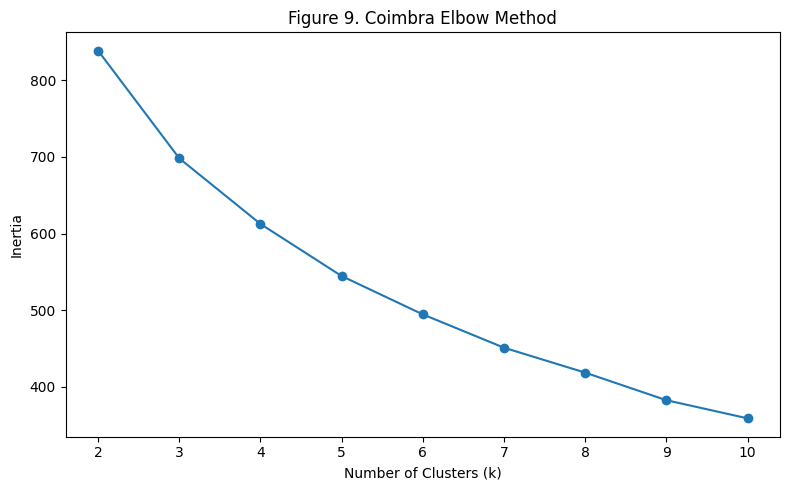

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(c_elbow_df["k"], c_elbow_df["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Figure 9. Coimbra Elbow Method")
plt.xticks(list(k_values))
plt.tight_layout()
plt.show()


#### Coimbra silhouette score

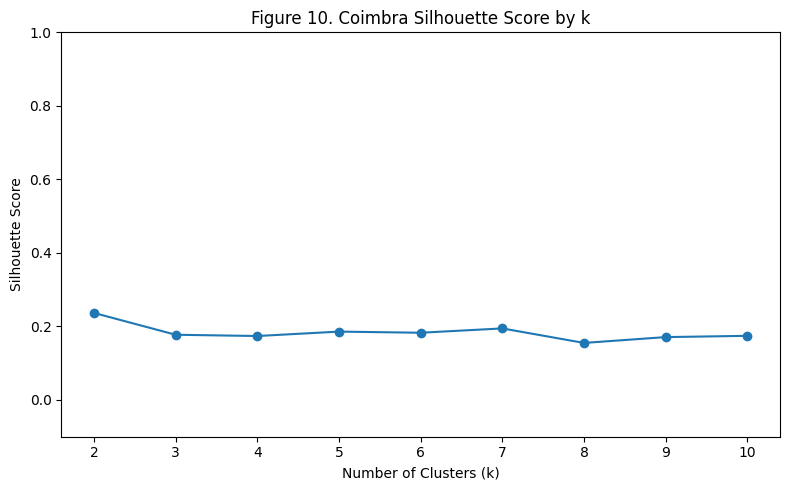

,k,inertia,silhouette_euclidean
0,2,838.827100,0.236727
5,7,450.851846,0.194602
3,5,544.464780,0.185935
4,6,494.378624,0.182839
1,3,698.234576,0.177388
8,10,358.597163,0.174461
2,4,612.520239,0.173927
7,9,382.302260,0.170985
6,8,418.302944,0.155148


In [59]:
plt.figure(figsize=(8, 5))
plt.plot(c_elbow_df["k"], c_elbow_df["silhouette_euclidean"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Figure 10. Coimbra Silhouette Score by k")
plt.xticks(list(k_values))
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

c_elbow_df.sort_values("silhouette_euclidean", ascending=False)


#### Coimbra final K-means model

In [60]:
best_k_c = int(c_elbow_df.sort_values("silhouette_euclidean", ascending=False).iloc[0]["k"])
c_final_model, c_final_labels = run_kmeans(X_c_standard, best_k_c)

print("Best Coimbra k based on silhouette:", best_k_c)

c_cluster_comparison = pd.crosstab(
    pd.Series(c_final_labels, name="cluster"),
    coimbra_df["diagnosis_group"],
    margins=True
)

c_label_scores = compare_clusters_to_labels(c_final_labels, y_c, "Coimbra")

display(c_cluster_comparison)
pd.DataFrame([c_label_scores])


Best Coimbra k based on silhouette: 2


diagnosis_group,Healthy Control,Patient,All
cluster,,,
0,39,39,78
1,13,25,38
All,52,64,116


,dataset,adjusted_rand_index,normalized_mutual_info
0,Coimbra,0.001866,0.017052


#### Coimbra distance metrics

In [61]:
c_distance_df = compare_distance_metrics(X_c_standard, c_final_labels)
c_distance_df


,distance_metric,silhouette_score
2,cosine,0.304800
1,manhattan,0.264969
0,euclidean,0.236727


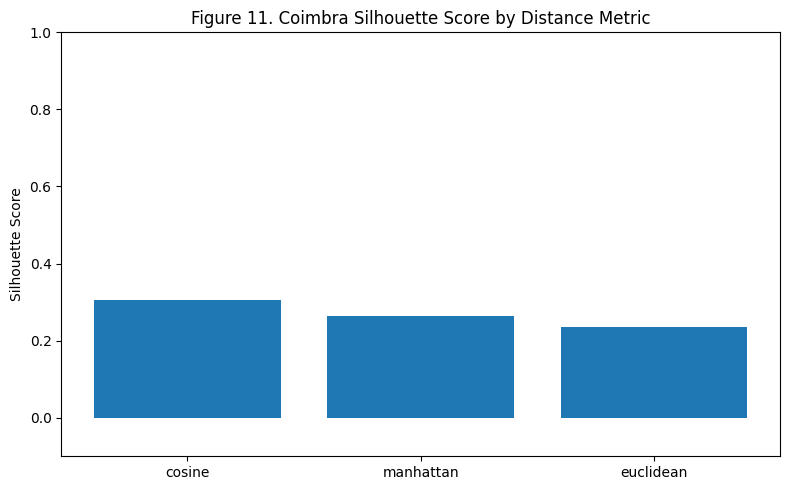

In [62]:
plt.figure(figsize=(8, 5))
plt.bar(c_distance_df["distance_metric"], c_distance_df["silhouette_score"])
plt.ylabel("Silhouette Score")
plt.title("Figure 11. Coimbra Silhouette Score by Distance Metric")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Coimbra PCA visualization

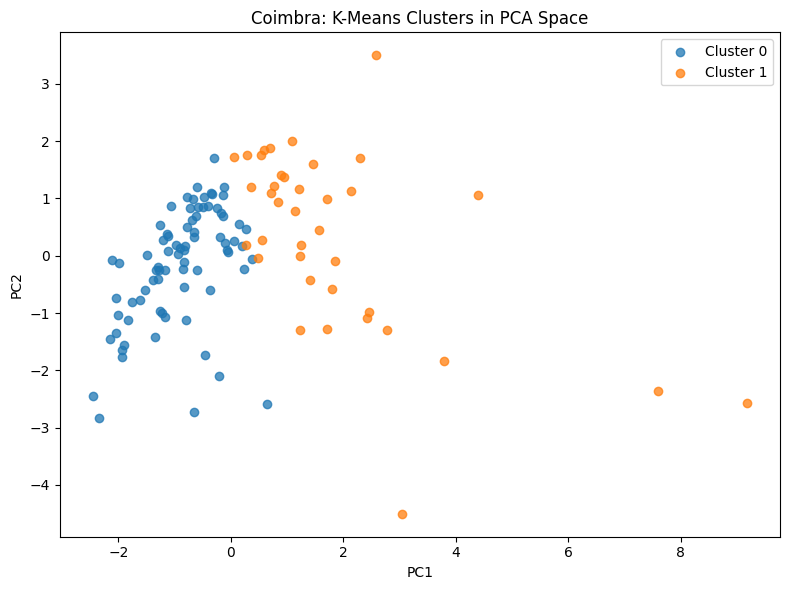

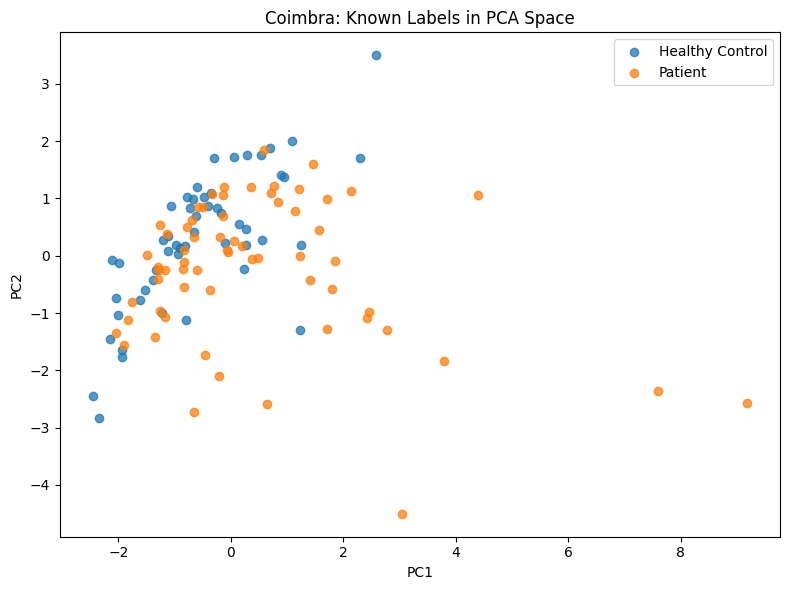

In [63]:
c_pca_df = plot_pca_view(
    X_c_standard,
    c_final_labels,
    y_c,
    "Coimbra",
    {0: "Healthy Control", 1: "Patient"}
)


#### Coimbra interpretation

For Coimbra, I expected weaker cluster separation than Wisconsin because the features are indirect biomarkers rather than tumor image measurements. K-means may still find patient profiles, but those profiles may not align perfectly with healthy control versus breast cancer patient status.


### Part C — Comparison across both datasets

#### Wisconsin vs. Coimbra comparison

Now I compare the final K-means results across both datasets.


In [64]:
combined_summary = pd.DataFrame([
    {
        "dataset": "Wisconsin",
        "best_k": best_k_w,
        "silhouette_euclidean": silhouette_score(X_w_standard, w_final_labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_w, w_final_labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_w, w_final_labels)
    },
    {
        "dataset": "Coimbra",
        "best_k": best_k_c,
        "silhouette_euclidean": silhouette_score(X_c_standard, c_final_labels, metric="euclidean"),
        "adjusted_rand_index": adjusted_rand_score(y_c, c_final_labels),
        "normalized_mutual_info": normalized_mutual_info_score(y_c, c_final_labels)
    }
])

combined_summary


,dataset,best_k,silhouette_euclidean,adjusted_rand_index,normalized_mutual_info
0,Wisconsin,2,0.344974,0.670721,0.554612
1,Coimbra,2,0.236727,0.001866,0.017052


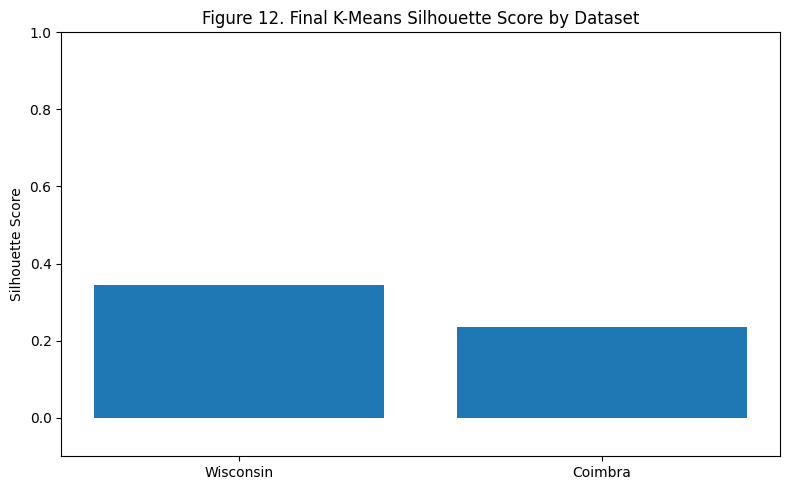

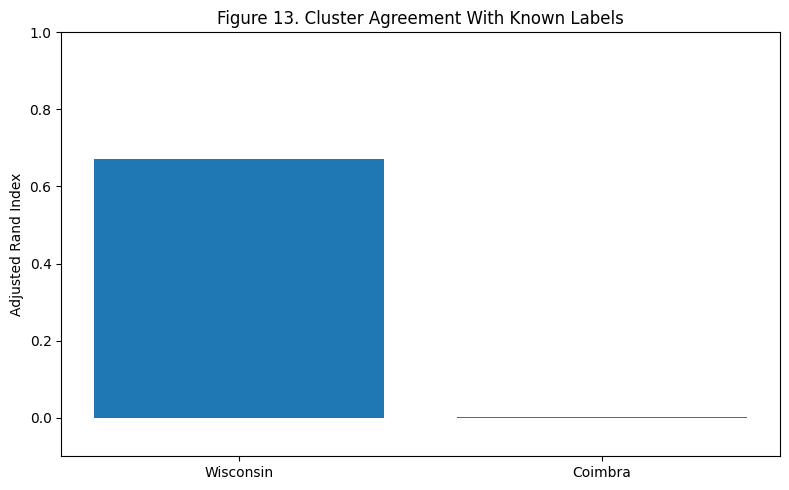

In [65]:
plt.figure(figsize=(8, 5))
plt.bar(combined_summary["dataset"], combined_summary["silhouette_euclidean"])
plt.ylabel("Silhouette Score")
plt.title("Figure 12. Final K-Means Silhouette Score by Dataset")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(combined_summary["dataset"], combined_summary["adjusted_rand_index"])
plt.ylabel("Adjusted Rand Index")
plt.title("Figure 13. Cluster Agreement With Known Labels")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Week 10 summary

In [66]:
print("Week 10 K-Means Summary")


print("Wisconsin:")
print(f"Best k: {best_k_w}")
print(f"Silhouette score: {combined_summary.loc[combined_summary['dataset']=='Wisconsin', 'silhouette_euclidean'].iloc[0]:.4f}")
print(f"Adjusted Rand Index: {combined_summary.loc[combined_summary['dataset']=='Wisconsin', 'adjusted_rand_index'].iloc[0]:.4f}")

print("\nCoimbra:")
print(f"Best k: {best_k_c}")
print(f"Silhouette score: {combined_summary.loc[combined_summary['dataset']=='Coimbra', 'silhouette_euclidean'].iloc[0]:.4f}")
print(f"Adjusted Rand Index: {combined_summary.loc[combined_summary['dataset']=='Coimbra', 'adjusted_rand_index'].iloc[0]:.4f}")

print("\nInterpretation:")
print("K-means does not use diagnosis labels. The label comparison is only used afterward to see whether natural clusters resemble known outcomes.")


Week 10 K-Means Summary
Wisconsin:
Best k: 2
Silhouette score: 0.3450
Adjusted Rand Index: 0.6707

Coimbra:
Best k: 2
Silhouette score: 0.2367
Adjusted Rand Index: 0.0019

Interpretation:
K-means does not use diagnosis labels. The label comparison is only used afterward to see whether natural clusters resemble known outcomes.


#### Week 10 findings and interpretation

This week showed me that clustering answers a different question from the supervised models in earlier weeks. Supervised models ask whether the model can predict the known label. K-means asks whether the observations naturally group together based only on their features.

Feature scaling was one of the most important parts of this notebook. Since K-means is distance-based, variables with large numeric ranges can dominate the clustering if scaling is not applied. This affected both datasets. In Wisconsin, tumor area and perimeter have much larger ranges than smoothness or symmetry. In Coimbra, MCP-1 and insulin have much larger ranges than age or BMI.

The elbow method helped me inspect how inertia changed as the number of clusters increased. However, the elbow method can be subjective, so I also used the silhouette score as a more numeric way to compare cluster separation. I also compared silhouette scores under different distance metrics. Standard K-means uses Euclidean distance, but checking Manhattan and cosine silhouette scores helped me understand how cluster quality changes depending on how distance is measured.

For the Wisconsin dataset, I expected stronger cluster alignment with diagnosis because tumor morphology features are directly related to benign versus malignant tumors. For Coimbra, I expected weaker alignment because biomarkers are more indirect and the dataset is smaller. Overall, the comparison helps show that tumor image-based data may contain stronger natural structure related to diagnosis than clinical biomarker data.


## 5. Week 11 — Clustering 2: DBSCAN & Hierarchical (HAC)

#### DBSCAN, HAC, Linkage Methods, and Dendrograms

**Integrated Capstone Project:** Wisconsin and Coimbra Breast Cancer Datasets  
**Week topic:** DBSCAN, hierarchical agglomerative clustering, linkage methods, and dendrograms

#### Notebook purpose

For Week 11, I am applying clustering methods to both of my capstone datasets:

1. **Breast Cancer Wisconsin Diagnostic dataset** — tumor image-based measurements.
2. **Breast Cancer Coimbra dataset** — clinical and blood-based biomarkers.

This week is unsupervised learning. The clustering models do **not** use the diagnosis label when forming groups. I only compare clusters to the known label afterward to help interpret whether natural patterns in the data resemble the known cancer outcome.

For this notebook, I focus on:

- Density-based spatial clustering of applications with noise (**DBSCAN**)
- DBSCAN `eps` and `min_samples`
- Noise points
- Hierarchical agglomerative clustering (**HAC**)
- Linkage methods: ward, complete, average, and single
- Dendrograms
- Wisconsin vs. Coimbra interpretation

#### Helper functions

These helper functions keep the Wisconsin and Coimbra analyses consistent.

In [67]:
def scale_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return pd.DataFrame(X_scaled, columns=X.columns, index=X.index), scaler


def make_pca_df(X_scaled):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    return pd.DataFrame({"PC1": coords[:, 0], "PC2": coords[:, 1]}, index=X_scaled.index), pca


def safe_silhouette(X_scaled, labels, remove_noise=False):
    labels = np.asarray(labels)
    if remove_noise:
        mask = labels != -1
        if mask.sum() < 3:
            return np.nan
        X_used = X_scaled.loc[mask]
        labels_used = labels[mask]
    else:
        X_used = X_scaled
        labels_used = labels
    if len(np.unique(labels_used)) < 2 or len(np.unique(labels_used)) >= len(labels_used):
        return np.nan
    return silhouette_score(X_used, labels_used)


def cluster_summary(dataset, method, labels, y_true, X_scaled):
    labels = np.asarray(labels)
    clusters_no_noise = [x for x in np.unique(labels) if x != -1]
    n_noise = int((labels == -1).sum())
    return {
        "dataset": dataset,
        "method": method,
        "clusters_excluding_noise": len(clusters_no_noise),
        "noise_points": n_noise,
        "noise_rate": n_noise / len(labels),
        "silhouette_all_points": safe_silhouette(X_scaled, labels, remove_noise=False),
        "silhouette_without_noise": safe_silhouette(X_scaled, labels, remove_noise=True),
        "ARI_vs_known_label": adjusted_rand_score(y_true, labels),
        "NMI_vs_known_label": normalized_mutual_info_score(y_true, labels)
    }


def plot_clusters(pca_df, labels, title):
    plot_df = pca_df.copy()
    plot_df["cluster"] = labels
    plt.figure(figsize=(8, 6))
    for cluster in sorted(plot_df["cluster"].unique()):
        group = plot_df[plot_df["cluster"] == cluster]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=f"Cluster {cluster}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_known_labels(pca_df, y_true, label_map, title):
    plot_df = pca_df.copy()
    plot_df["known_label"] = y_true
    plt.figure(figsize=(8, 6))
    for value, label in label_map.items():
        group = plot_df[plot_df["known_label"] == value]
        plt.scatter(group["PC1"], group["PC2"], alpha=0.75, label=label)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def dbscan_grid_search(X_scaled, y_true, dataset_name, eps_values, min_samples_values):
    rows = []
    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X_scaled)
            row = cluster_summary(dataset_name, f"DBSCAN eps={eps}, min_samples={min_samples}", labels, y_true, X_scaled)
            row["eps"] = eps
            row["min_samples"] = min_samples
            rows.append(row)
    return pd.DataFrame(rows)


def choose_dbscan(search_df):
    valid = search_df[(search_df["clusters_excluding_noise"] >= 2) & (search_df["noise_rate"] < 0.50)].copy()
    if len(valid) > 0:
        return valid.sort_values(["silhouette_without_noise", "noise_rate"], ascending=[False, True]).iloc[0]
    return search_df.sort_values(["silhouette_without_noise", "noise_rate"], ascending=[False, True]).iloc[0]


def hac_linkage_comparison(X_scaled, y_true, dataset_name):
    rows = []
    labels_by_linkage = {}
    for method in ["ward", "complete", "average", "single"]:
        model = AgglomerativeClustering(n_clusters=2, linkage=method)
        labels = model.fit_predict(X_scaled)
        row = cluster_summary(dataset_name, f"HAC linkage={method}", labels, y_true, X_scaled)
        row["linkage"] = method
        rows.append(row)
        labels_by_linkage[method] = labels
    return pd.DataFrame(rows), labels_by_linkage


### Part A — Wisconsin (Diagnostic)

#### Load and prepare Wisconsin dataset

The sklearn version uses `0 = malignant` and `1 = benign`, so I recode it as `1 = malignant` and `0 = benign`. The clustering models do not use this label during training.

#### Wisconsin features, scaling, and PCA view

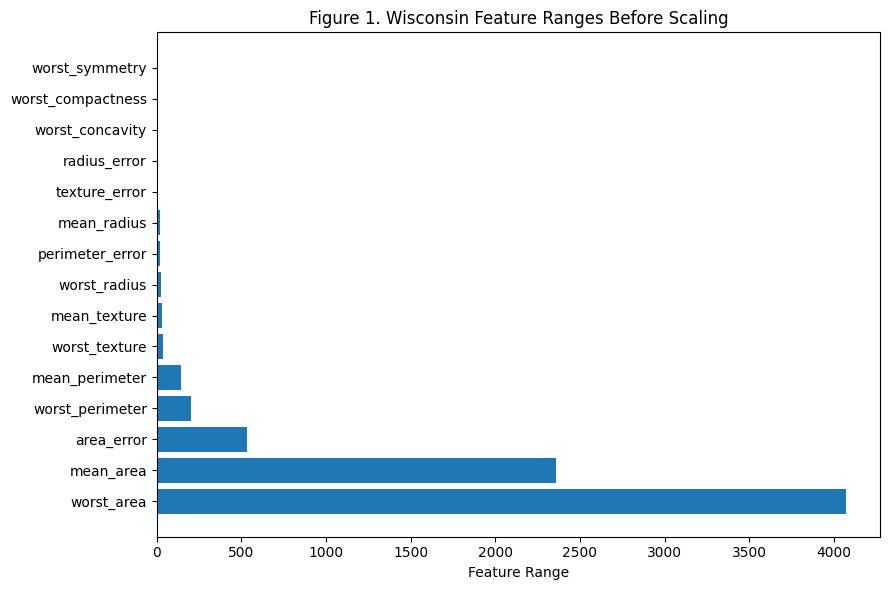

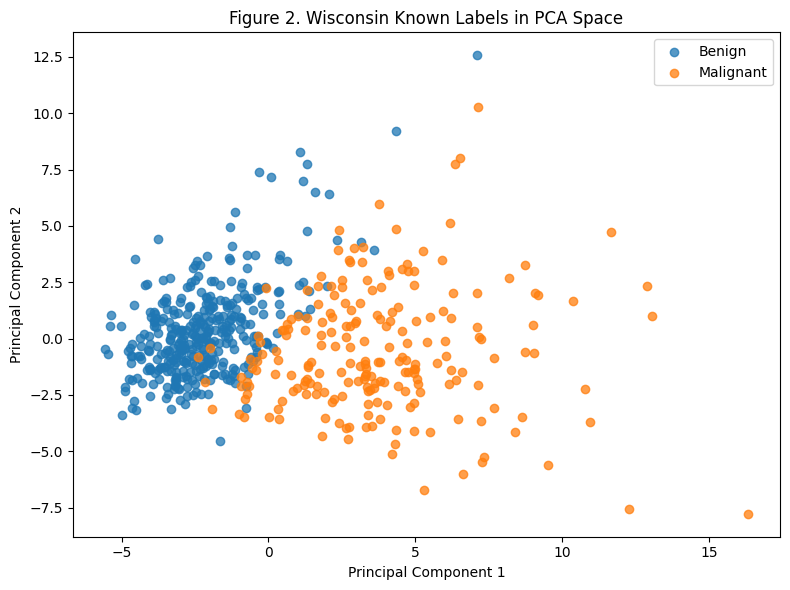

In [68]:
wisconsin_features = [c for c in wisconsin_df.columns if c not in ["diagnosis_malignant", "diagnosis_label"]]
X_w = wisconsin_df[wisconsin_features]
y_w = wisconsin_df["diagnosis_malignant"]

w_scale = X_w.agg(["min", "max", "mean", "std"]).T
w_scale["range"] = w_scale["max"] - w_scale["min"]
w_scale = w_scale.sort_values("range", ascending=False).head(15)

plt.figure(figsize=(9, 6))
plt.barh(w_scale.index, w_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 1. Wisconsin Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

X_w_scaled, w_scaler = scale_features(X_w)
w_pca_df, w_pca = make_pca_df(X_w_scaled)

plot_known_labels(w_pca_df, y_w, {0: "Benign", 1: "Malignant"}, "Figure 2. Wisconsin Known Labels in PCA Space")


#### Wisconsin DBSCAN k-distance plot

I use the 5th nearest neighbor distance as a guide for choosing `eps`. A sharp bend in this curve can suggest a reasonable starting `eps`.

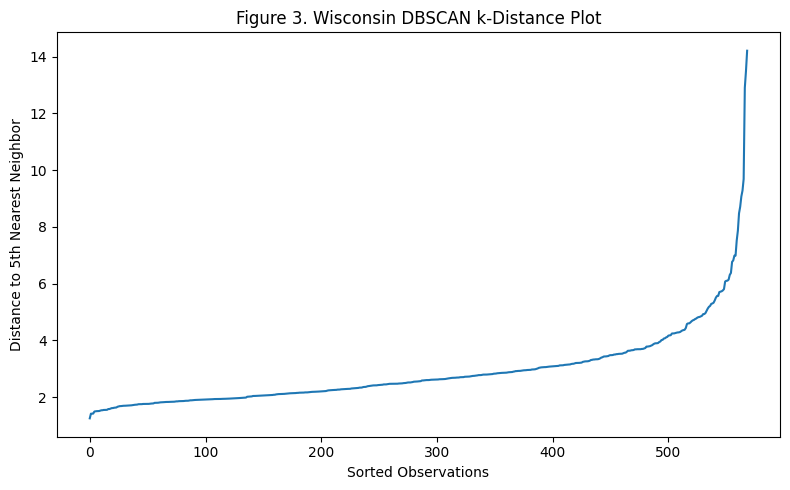

,0
count,569.000000
mean,2.904996
std,1.441666
min,1.248460
25%,2.036675
50%,2.552499
75%,3.239679
max,14.212836


In [69]:
min_samples_start = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_start).fit(X_w_scaled)
distances, indices = nbrs.kneighbors(X_w_scaled)
k_distances = np.sort(distances[:, min_samples_start - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Sorted Observations")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("Figure 3. Wisconsin DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

pd.Series(k_distances).describe()


#### Wisconsin DBSCAN parameter search

In [70]:
w_search = dbscan_grid_search(
    X_scaled=X_w_scaled,
    y_true=y_w,
    dataset_name="Wisconsin",
    eps_values=[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5],
    min_samples_values=[3, 5, 8, 10]
)

w_search.sort_values(["clusters_excluding_noise", "silhouette_without_noise", "noise_rate"], ascending=[False, False, True]).head(15)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,eps,min_samples
4,Wisconsin,"DBSCAN eps=2.0, min_samples=3",7,336,0.590510,-0.203959,0.081566,0.142157,0.229118,2.0,3
0,Wisconsin,"DBSCAN eps=1.5, min_samples=3",6,513,0.901582,-0.338198,0.159162,-0.042527,0.093148,1.5,3
8,Wisconsin,"DBSCAN eps=2.5, min_samples=3",5,200,0.351494,-0.075507,0.076333,0.214740,0.153876,2.5,3
5,Wisconsin,"DBSCAN eps=2.0, min_samples=5",4,371,0.652021,-0.198514,0.097753,0.096351,0.203526,2.0,5
12,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.074060,3.0,3
11,Wisconsin,"DBSCAN eps=2.5, min_samples=10",2,264,0.463972,0.030703,0.294094,0.264893,0.232743,2.5,10
10,Wisconsin,"DBSCAN eps=2.5, min_samples=8",2,252,0.442882,0.017805,0.168579,0.210034,0.160210,2.5,8
9,Wisconsin,"DBSCAN eps=2.5, min_samples=5",2,224,0.393673,-0.016791,0.129459,0.207788,0.145263,2.5,5
24,Wisconsin,"DBSCAN eps=4.5, min_samples=3",1,28,0.049209,0.461266,NaN,0.024331,0.013636,4.5,3
25,Wisconsin,"DBSCAN eps=4.5, min_samples=5",1,32,0.056239,0.449810,NaN,0.025968,0.013646,4.5,5


#### Wisconsin final DBSCAN model

I choose a DBSCAN model that finds at least two clusters and avoids marking too much of the dataset as noise.

Selected Wisconsin eps: 3.0
Selected Wisconsin min_samples: 3


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label
0,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.07406


diagnosis_label,Benign,Malignant,All
DBSCAN_cluster,,,
-1,40,71,111
0,317,137,454
1,0,4,4
All,357,212,569


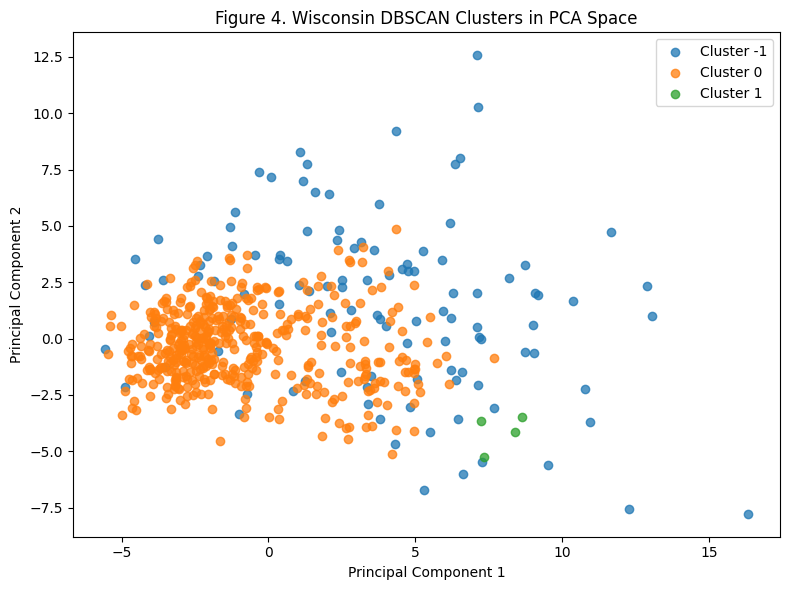

In [71]:
w_best_row = choose_dbscan(w_search)
w_best_eps = float(w_best_row["eps"])
w_best_min_samples = int(w_best_row["min_samples"])

w_dbscan = DBSCAN(eps=w_best_eps, min_samples=w_best_min_samples)
w_dbscan_labels = w_dbscan.fit_predict(X_w_scaled)
w_dbscan_summary = cluster_summary("Wisconsin", f"DBSCAN eps={w_best_eps}, min_samples={w_best_min_samples}", w_dbscan_labels, y_w, X_w_scaled)

print("Selected Wisconsin eps:", w_best_eps)
print("Selected Wisconsin min_samples:", w_best_min_samples)
display(pd.DataFrame([w_dbscan_summary]))

display(pd.crosstab(pd.Series(w_dbscan_labels, name="DBSCAN_cluster"), wisconsin_df["diagnosis_label"], margins=True))
plot_clusters(w_pca_df, w_dbscan_labels, "Figure 4. Wisconsin DBSCAN Clusters in PCA Space")


#### Wisconsin DBSCAN interpretation

DBSCAN is helpful because it can identify unusual observations as noise. In healthcare data, this could represent cases that do not fit neatly into the main groups. For Wisconsin, I expect DBSCAN to show more useful structure than Coimbra because tumor morphology features are directly related to diagnosis.

#### Wisconsin HAC linkage comparison

I compare Ward, complete, average, and single linkage using two clusters.

In [72]:
w_hac_df, w_hac_labels = hac_linkage_comparison(X_w_scaled, y_w, "Wisconsin")
w_hac_df.sort_values("silhouette_all_points", ascending=False)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
1,Wisconsin,HAC linkage=complete,2,0,0.0,0.660667,0.660667,0.004828,0.010182,complete
3,Wisconsin,HAC linkage=single,2,0,0.0,0.660667,0.660667,0.004828,0.010182,single
2,Wisconsin,HAC linkage=average,2,0,0.0,0.633978,0.633978,0.007276,0.015086,average
0,Wisconsin,HAC linkage=ward,2,0,0.0,0.339385,0.339385,0.575041,0.456915,ward


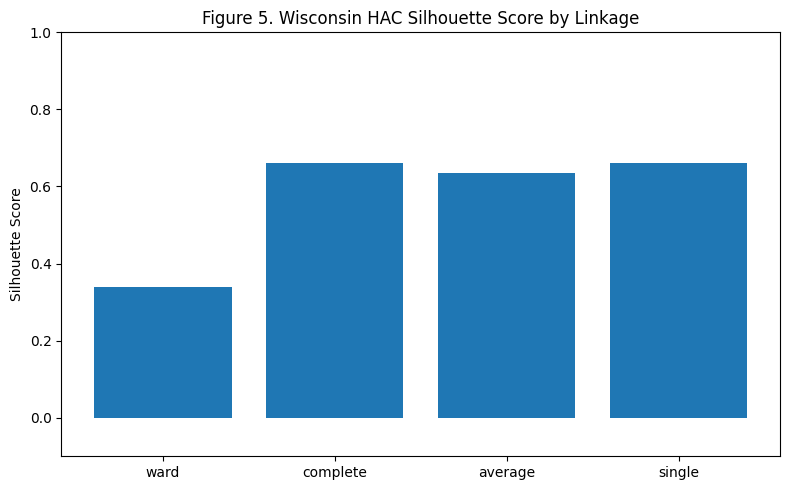

In [73]:
plt.figure(figsize=(8, 5))
plt.bar(w_hac_df["linkage"], w_hac_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 5. Wisconsin HAC Silhouette Score by Linkage")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Wisconsin final HAC model

Best Wisconsin linkage: complete


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
1,Wisconsin,HAC linkage=complete,2,0,0.0,0.660667,0.660667,0.004828,0.010182,complete


diagnosis_label,Benign,Malignant,All
HAC_cluster,,,
0,357,210,567
1,0,2,2
All,357,212,569


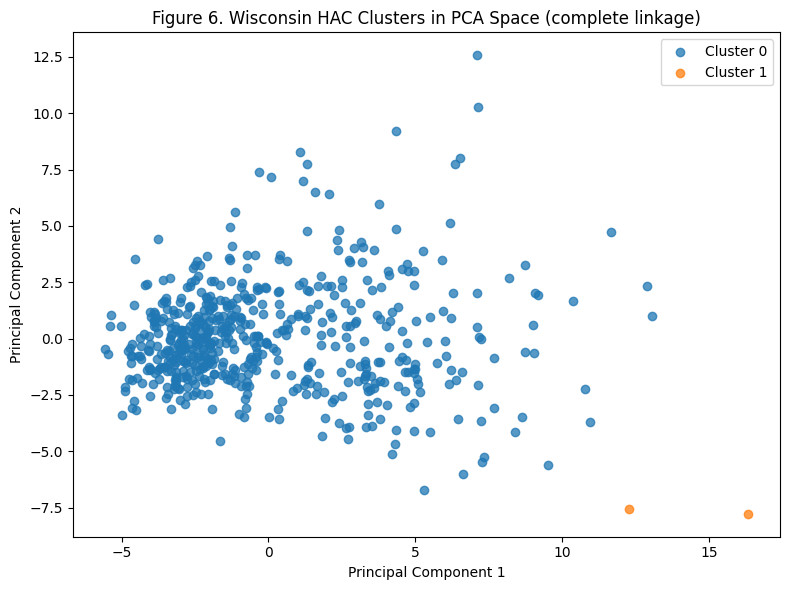

In [74]:
w_best_hac = w_hac_df.sort_values("silhouette_all_points", ascending=False).iloc[0]
w_best_linkage = w_best_hac["linkage"]
w_best_hac_labels = w_hac_labels[w_best_linkage]

print("Best Wisconsin linkage:", w_best_linkage)
display(pd.DataFrame([w_best_hac]))
display(pd.crosstab(pd.Series(w_best_hac_labels, name="HAC_cluster"), wisconsin_df["diagnosis_label"], margins=True))
plot_clusters(w_pca_df, w_best_hac_labels, f"Figure 6. Wisconsin HAC Clusters in PCA Space ({w_best_linkage} linkage)")


#### Wisconsin dendrograms

I use a random sample of 80 Wisconsin observations so the dendrograms stay readable.

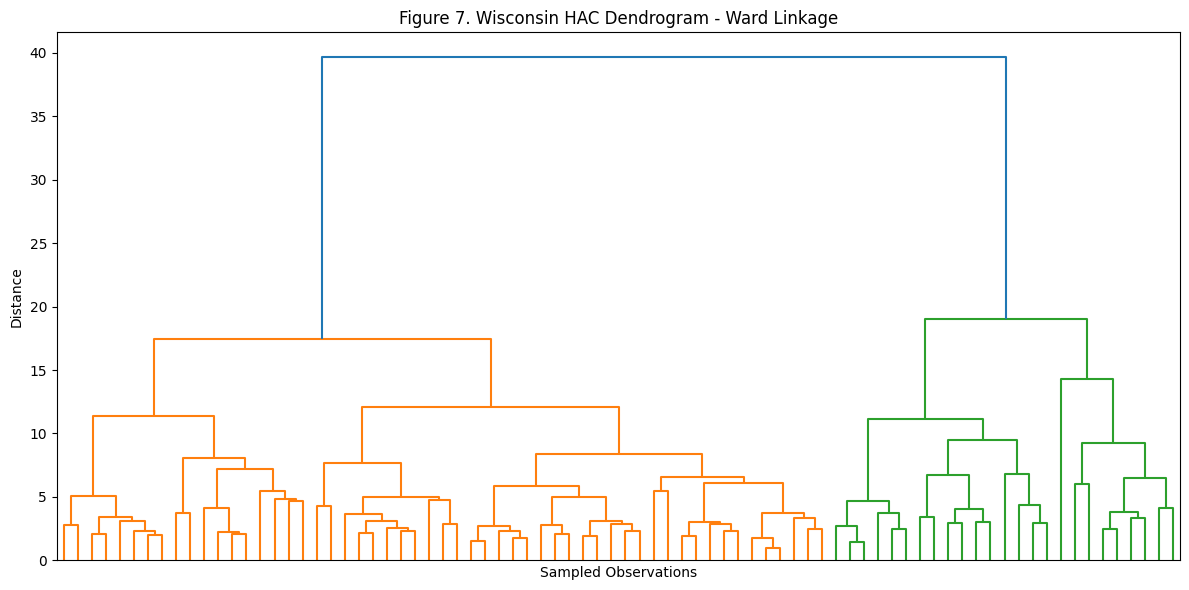

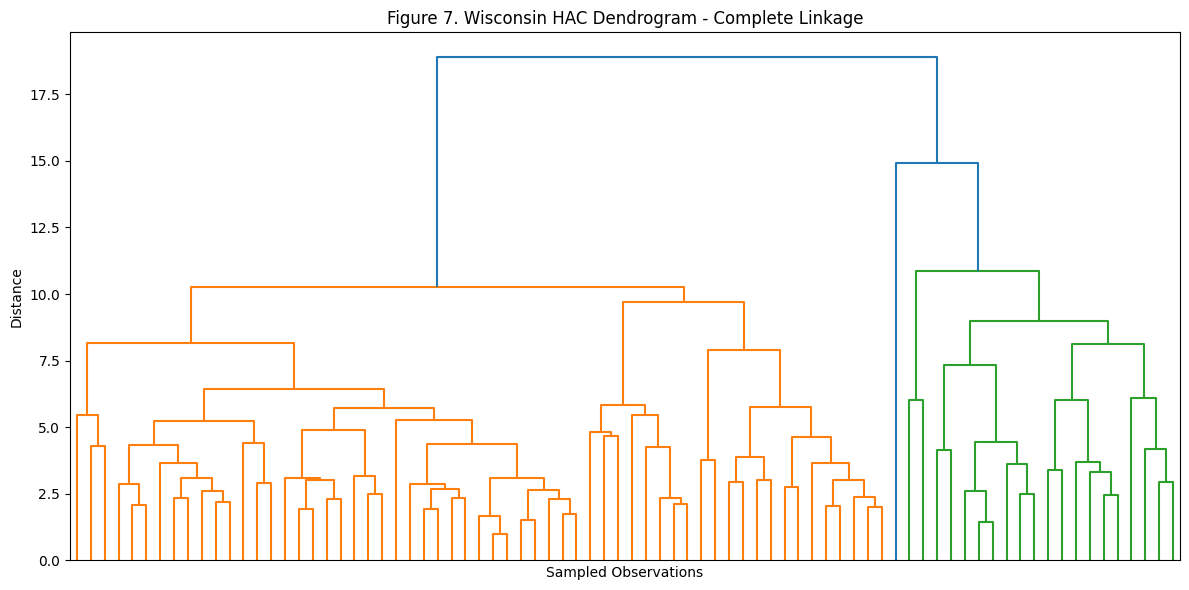

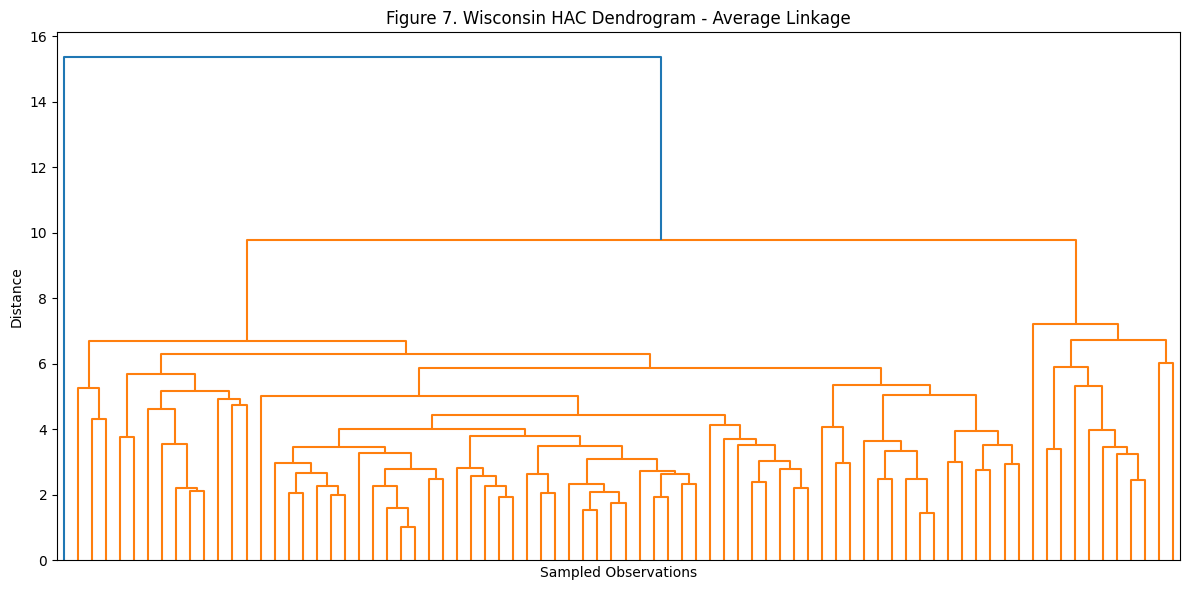

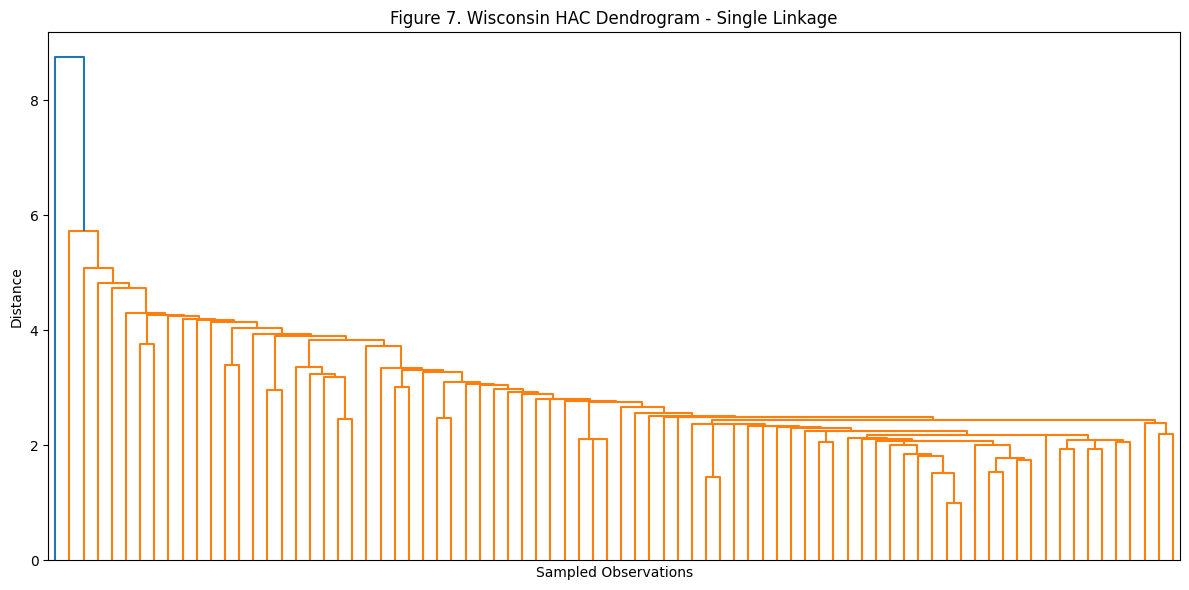

In [75]:
w_sample = X_w_scaled.sample(n=80, random_state=42)

for method in ["ward", "complete", "average", "single"]:
    linked = linkage(w_sample, method=method)
    plt.figure(figsize=(12, 6))
    dendrogram(linked, no_labels=True)
    plt.title(f"Figure 7. Wisconsin HAC Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Sampled Observations")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


#### Wisconsin HAC interpretation

HAC shows cluster structure as a hierarchy. The linkage method matters because each method defines distance between clusters differently. Ward linkage often creates compact clusters, while single linkage can create chain-like clusters.

### Part B — Coimbra (clinical & blood biomarkers)

#### Load and prepare Coimbra dataset

The Coimbra target is `Classification`, where `1 = healthy control` and `2 = breast cancer patient`. I recode it so `1 = patient` and `0 = healthy control`.

#### Coimbra features, scaling, and PCA view

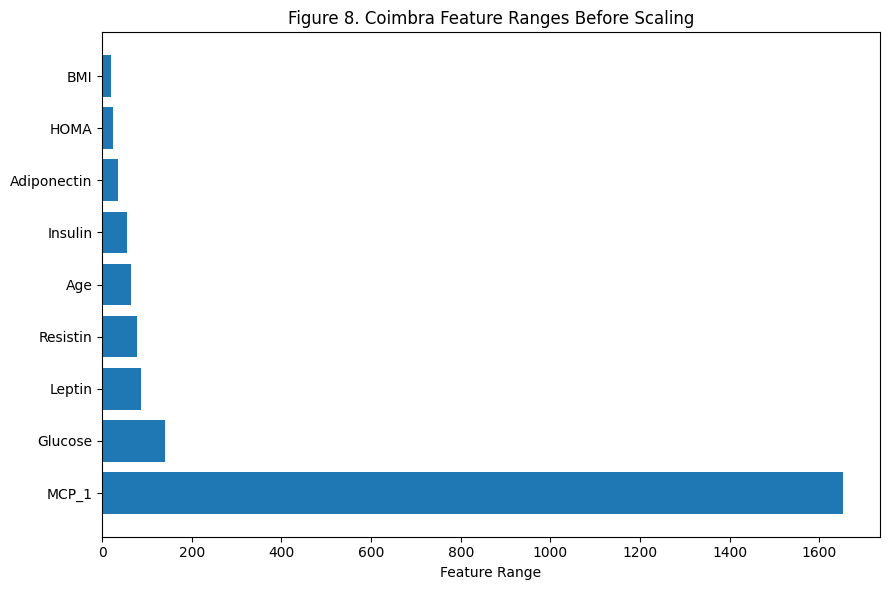

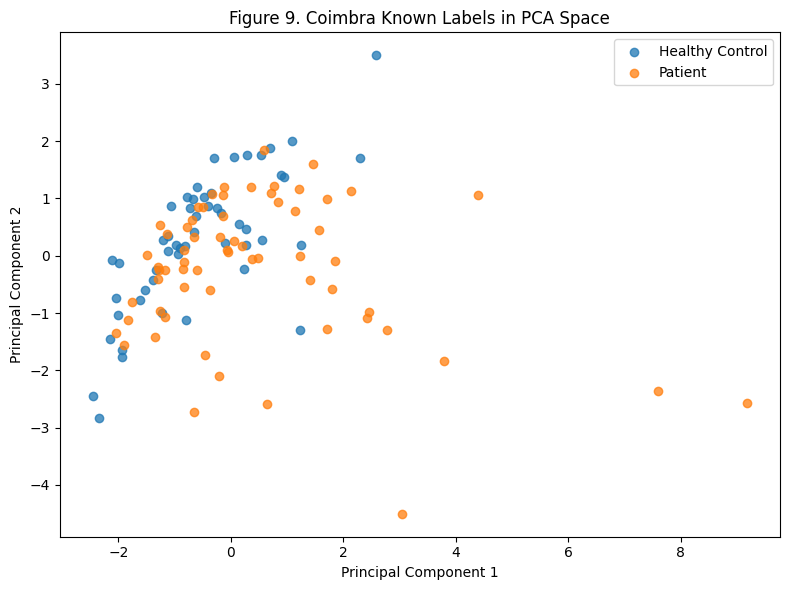

In [76]:
coimbra_features = [c for c in coimbra_df.columns if c not in ["Classification", "breast_cancer_present", "diagnosis_group"]]
X_c = coimbra_df[coimbra_features]
y_c = coimbra_df["breast_cancer_present"]

c_scale = X_c.agg(["min", "max", "mean", "std"]).T
c_scale["range"] = c_scale["max"] - c_scale["min"]
c_scale = c_scale.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(c_scale.index, c_scale["range"])
plt.xlabel("Feature Range")
plt.title("Figure 8. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

X_c_scaled, c_scaler = scale_features(X_c)
c_pca_df, c_pca = make_pca_df(X_c_scaled)

plot_known_labels(c_pca_df, y_c, {0: "Healthy Control", 1: "Patient"}, "Figure 9. Coimbra Known Labels in PCA Space")


#### Coimbra DBSCAN k-distance plot

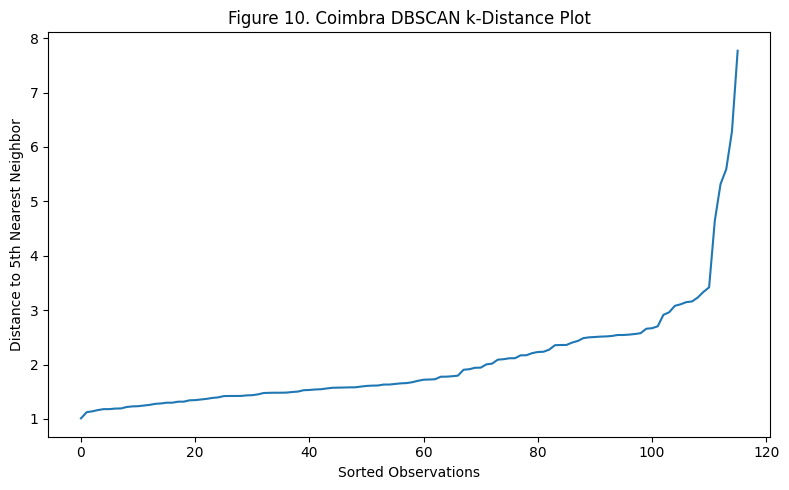

,0
count,116.000000
mean,2.041376
std,1.030259
min,1.010264
25%,1.429541
50%,1.666256
75%,2.410576
max,7.769947


In [77]:
nbrs = NearestNeighbors(n_neighbors=min_samples_start).fit(X_c_scaled)
distances, indices = nbrs.kneighbors(X_c_scaled)
k_distances_c = np.sort(distances[:, min_samples_start - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances_c)
plt.xlabel("Sorted Observations")
plt.ylabel("Distance to 5th Nearest Neighbor")
plt.title("Figure 10. Coimbra DBSCAN k-Distance Plot")
plt.tight_layout()
plt.show()

pd.Series(k_distances_c).describe()


#### Coimbra DBSCAN parameter search

In [78]:
c_search = dbscan_grid_search(
    X_scaled=X_c_scaled,
    y_true=y_c,
    dataset_name="Coimbra",
    eps_values=[0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0],
    min_samples_values=[3, 4, 5, 8]
)

c_search.sort_values(["clusters_excluding_noise", "silhouette_without_noise", "noise_rate"], ascending=[False, False, True]).head(15)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,eps,min_samples
4,Coimbra,"DBSCAN eps=1.0, min_samples=3",3,103,0.887931,-0.201058,0.427230,0.008383,0.055661,1.0,3
9,Coimbra,"DBSCAN eps=1.2, min_samples=4",3,87,0.750000,-0.185959,0.168688,0.015203,0.020855,1.2,4
8,Coimbra,"DBSCAN eps=1.2, min_samples=3",3,78,0.672414,-0.169562,0.087257,0.058686,0.062822,1.2,3
10,Coimbra,"DBSCAN eps=1.2, min_samples=5",2,97,0.836207,-0.129609,0.383494,-0.000290,0.009659,1.2,5
19,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.370690,0.099921,0.273187,0.038505,0.059288,1.8,8
20,Coimbra,"DBSCAN eps=2.0, min_samples=3",2,26,0.224138,0.112999,0.187200,0.004338,0.056723,2.0,3
15,Coimbra,"DBSCAN eps=1.5, min_samples=8",2,67,0.577586,-0.053837,0.185085,0.026535,0.020361,1.5,8
28,Coimbra,"DBSCAN eps=3.0, min_samples=3",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,3
29,Coimbra,"DBSCAN eps=3.0, min_samples=4",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,4
30,Coimbra,"DBSCAN eps=3.0, min_samples=5",1,6,0.051724,0.514759,NaN,-0.009195,0.021759,3.0,5


#### Coimbra final DBSCAN model

Selected Coimbra eps: 1.8
Selected Coimbra min_samples: 8


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label
0,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.37069,0.099921,0.273187,0.038505,0.059288


diagnosis_group,Healthy Control,Patient,All
DBSCAN_cluster,,,
-1,12,31,43
0,35,32,67
1,5,1,6
All,52,64,116


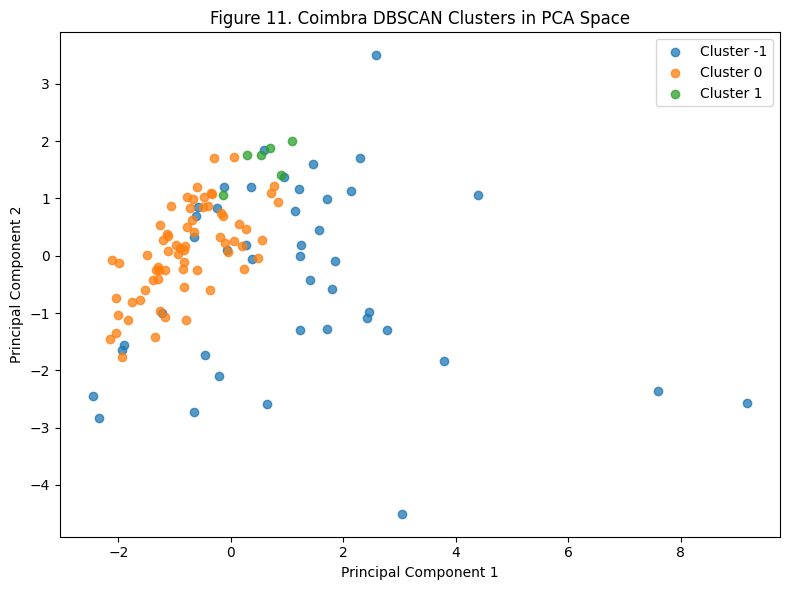

In [79]:
c_best_row = choose_dbscan(c_search)
c_best_eps = float(c_best_row["eps"])
c_best_min_samples = int(c_best_row["min_samples"])

c_dbscan = DBSCAN(eps=c_best_eps, min_samples=c_best_min_samples)
c_dbscan_labels = c_dbscan.fit_predict(X_c_scaled)
c_dbscan_summary = cluster_summary("Coimbra", f"DBSCAN eps={c_best_eps}, min_samples={c_best_min_samples}", c_dbscan_labels, y_c, X_c_scaled)

print("Selected Coimbra eps:", c_best_eps)
print("Selected Coimbra min_samples:", c_best_min_samples)
display(pd.DataFrame([c_dbscan_summary]))

display(pd.crosstab(pd.Series(c_dbscan_labels, name="DBSCAN_cluster"), coimbra_df["diagnosis_group"], margins=True))
plot_clusters(c_pca_df, c_dbscan_labels, "Figure 11. Coimbra DBSCAN Clusters in PCA Space")


#### Coimbra DBSCAN interpretation

Coimbra may produce more noise or weaker density clusters because the dataset is smaller and the predictors are indirect biomarkers rather than direct tumor measurements.

#### Coimbra HAC linkage comparison

In [80]:
c_hac_df, c_hac_labels = hac_linkage_comparison(X_c_scaled, y_c, "Coimbra")
c_hac_df.sort_values("silhouette_all_points", ascending=False)


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
3,Coimbra,HAC linkage=single,2,0,0.0,0.610903,0.610903,-0.005865,0.026782,single
1,Coimbra,HAC linkage=complete,2,0,0.0,0.580695,0.580695,-0.007897,0.038767,complete
2,Coimbra,HAC linkage=average,2,0,0.0,0.580695,0.580695,-0.007897,0.038767,average
0,Coimbra,HAC linkage=ward,2,0,0.0,0.178114,0.178114,-0.005994,0.002723,ward


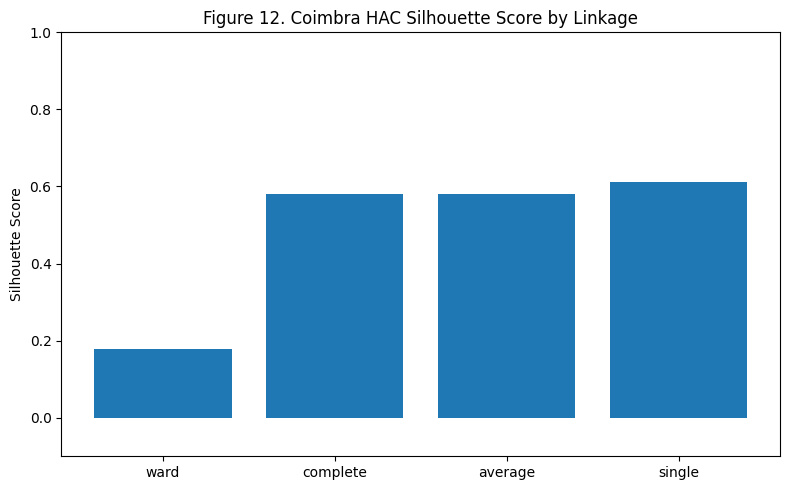

In [81]:
plt.figure(figsize=(8, 5))
plt.bar(c_hac_df["linkage"], c_hac_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 12. Coimbra HAC Silhouette Score by Linkage")
plt.ylim(-0.1, 1.0)
plt.tight_layout()
plt.show()


#### Coimbra final HAC model

Best Coimbra linkage: single


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
3,Coimbra,HAC linkage=single,2,0,0.0,0.610903,0.610903,-0.005865,0.026782,single


diagnosis_group,Healthy Control,Patient,All
HAC_cluster,,,
0,52,62,114
1,0,2,2
All,52,64,116


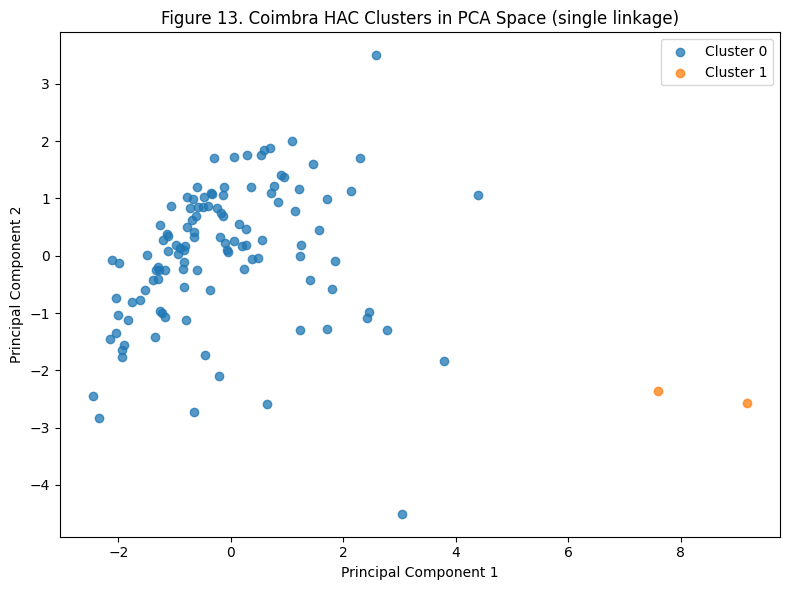

In [82]:
c_best_hac = c_hac_df.sort_values("silhouette_all_points", ascending=False).iloc[0]
c_best_linkage = c_best_hac["linkage"]
c_best_hac_labels = c_hac_labels[c_best_linkage]

print("Best Coimbra linkage:", c_best_linkage)
display(pd.DataFrame([c_best_hac]))
display(pd.crosstab(pd.Series(c_best_hac_labels, name="HAC_cluster"), coimbra_df["diagnosis_group"], margins=True))
plot_clusters(c_pca_df, c_best_hac_labels, f"Figure 13. Coimbra HAC Clusters in PCA Space ({c_best_linkage} linkage)")


#### Coimbra dendrograms

The Coimbra dataset is small enough that I can create dendrograms using the full dataset.

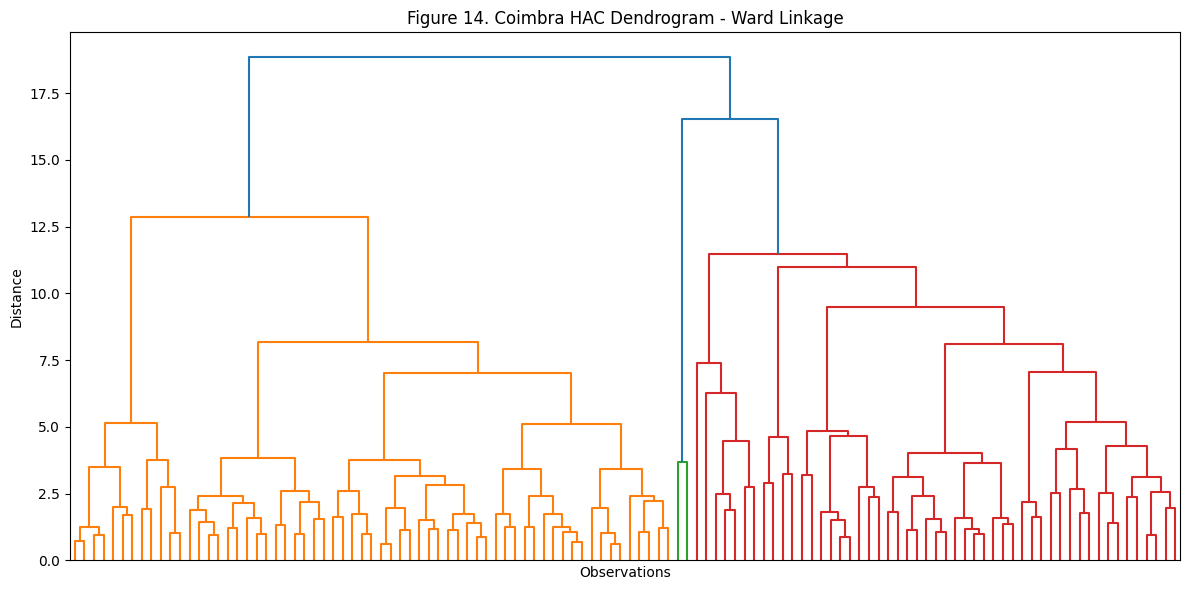

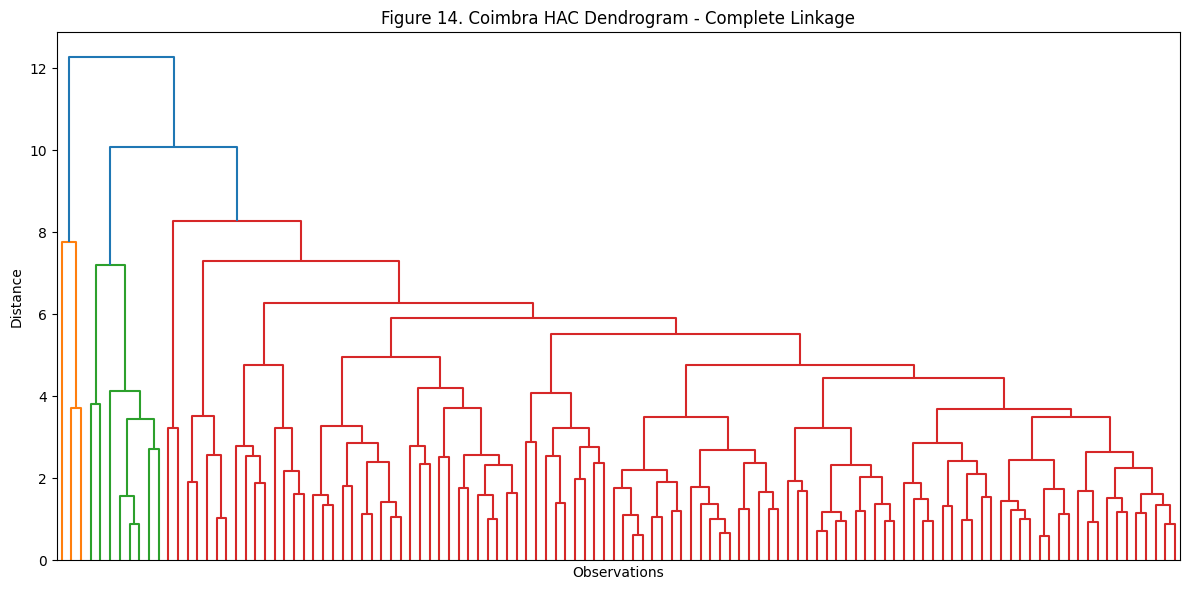

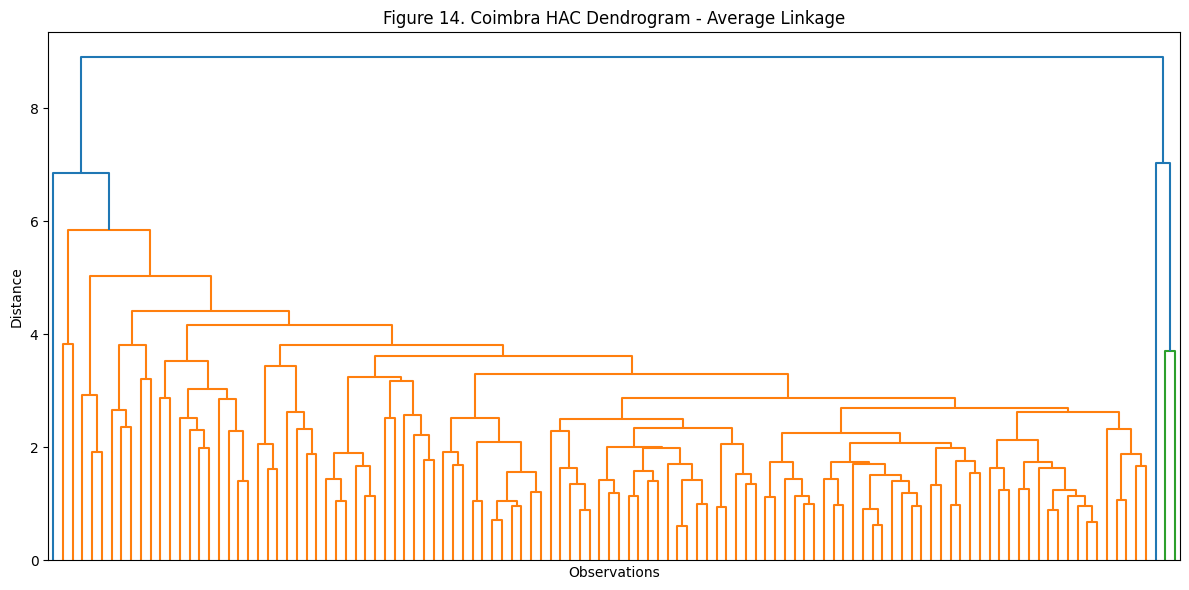

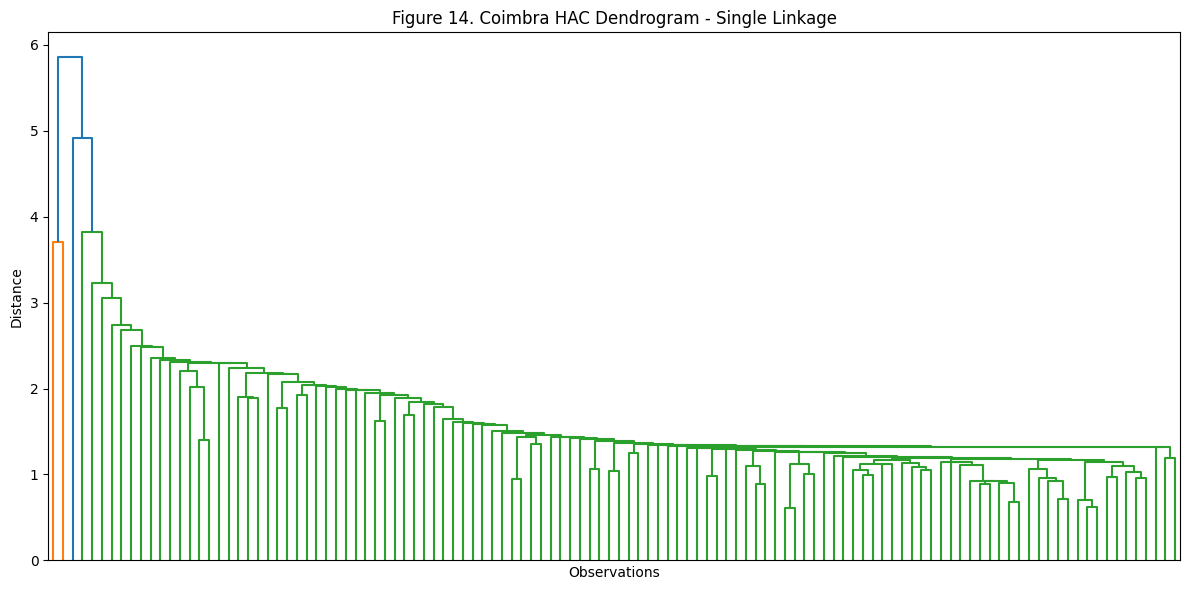

In [83]:
for method in ["ward", "complete", "average", "single"]:
    linked = linkage(X_c_scaled, method=method)
    plt.figure(figsize=(12, 6))
    dendrogram(linked, no_labels=True)
    plt.title(f"Figure 14. Coimbra HAC Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Observations")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()


#### Coimbra HAC interpretation

The dendrograms show how the patient profiles merge into larger clusters. If the dendrogram has large jumps in height, that may suggest more distinct groups. I expect Coimbra to show less clear separation than Wisconsin because its features are indirect clinical biomarkers.

### Part C — Comparison across both datasets

#### Compare DBSCAN and HAC across Wisconsin and Coimbra

In [84]:
combined_summary = pd.DataFrame([
    w_dbscan_summary,
    dict(w_best_hac),
    c_dbscan_summary,
    dict(c_best_hac)
])

combined_summary


,dataset,method,clusters_excluding_noise,noise_points,noise_rate,silhouette_all_points,silhouette_without_noise,ARI_vs_known_label,NMI_vs_known_label,linkage
0,Wisconsin,"DBSCAN eps=3.0, min_samples=3",2,111,0.195079,0.256691,0.435961,0.120337,0.074060,NaN
1,Wisconsin,HAC linkage=complete,2,0,0.000000,0.660667,0.660667,0.004828,0.010182,complete
2,Coimbra,"DBSCAN eps=1.8, min_samples=8",2,43,0.370690,0.099921,0.273187,0.038505,0.059288,NaN
3,Coimbra,HAC linkage=single,2,0,0.000000,0.610903,0.610903,-0.005865,0.026782,single


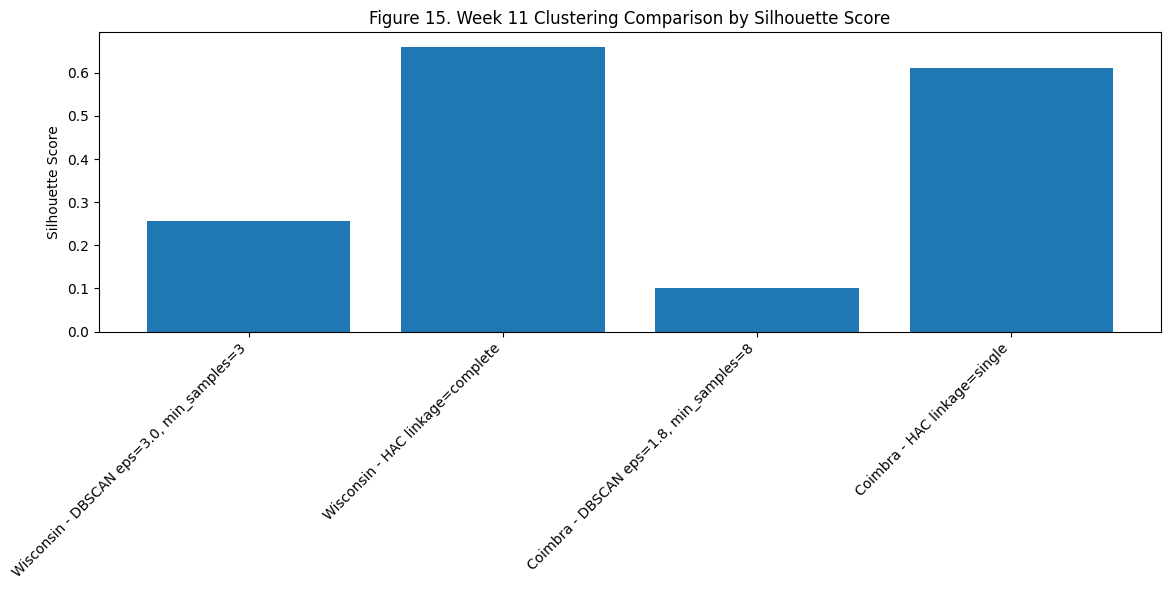

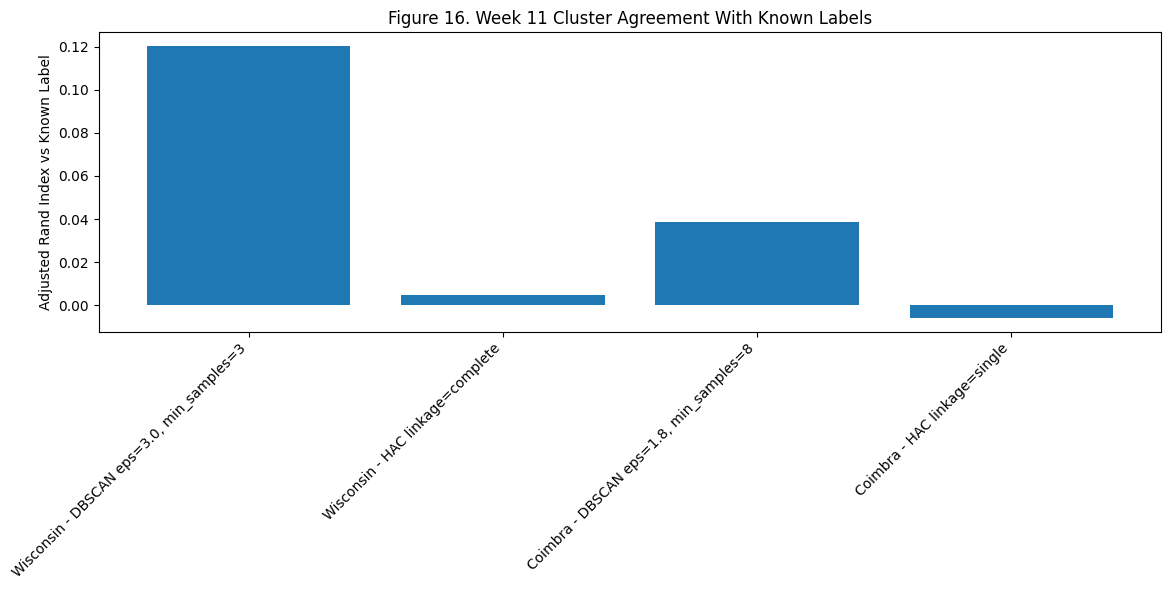

In [85]:
plot_df = combined_summary.copy()
plot_df["dataset_method"] = plot_df["dataset"] + " - " + plot_df["method"]

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset_method"], plot_df["silhouette_all_points"])
plt.ylabel("Silhouette Score")
plt.title("Figure 15. Week 11 Clustering Comparison by Silhouette Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(plot_df["dataset_method"], plot_df["ARI_vs_known_label"])
plt.ylabel("Adjusted Rand Index vs Known Label")
plt.title("Figure 16. Week 11 Cluster Agreement With Known Labels")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


#### Week 11 summary

In [86]:
print("Week 11 Clustering Summary")

print("Wisconsin DBSCAN:")
print(f"eps: {w_best_eps}")
print(f"min_samples: {w_best_min_samples}")
print(f"clusters excluding noise: {w_dbscan_summary['clusters_excluding_noise']}")
print(f"noise rate: {w_dbscan_summary['noise_rate']:.4f}")
print(f"silhouette without noise: {w_dbscan_summary['silhouette_without_noise']:.4f}")

print("Wisconsin HAC:")
print(f"best linkage: {w_best_linkage}")
print(f"silhouette: {w_best_hac['silhouette_all_points']:.4f}")
print(f"ARI vs diagnosis: {w_best_hac['ARI_vs_known_label']:.4f}")

print("Coimbra DBSCAN:")
print(f"eps: {c_best_eps}")
print(f"min_samples: {c_best_min_samples}")
print(f"clusters excluding noise: {c_dbscan_summary['clusters_excluding_noise']}")
print(f"noise rate: {c_dbscan_summary['noise_rate']:.4f}")
print(f"silhouette without noise: {c_dbscan_summary['silhouette_without_noise']:.4f}")

print("Coimbra HAC:")
print(f"best linkage: {c_best_linkage}")
print(f"silhouette: {c_best_hac['silhouette_all_points']:.4f}")
print(f"ARI vs known group: {c_best_hac['ARI_vs_known_label']:.4f}")


Week 11 Clustering Summary
Wisconsin DBSCAN:
eps: 3.0
min_samples: 3
clusters excluding noise: 2
noise rate: 0.1951
silhouette without noise: 0.4360
Wisconsin HAC:
best linkage: complete
silhouette: 0.6607
ARI vs diagnosis: 0.0048
Coimbra DBSCAN:
eps: 1.8
min_samples: 8
clusters excluding noise: 2
noise rate: 0.3707
silhouette without noise: 0.2732
Coimbra HAC:
best linkage: single
silhouette: 0.6109
ARI vs known group: -0.0059


#### Week 11 findings and interpretation

This week helped me compare two clustering approaches that work differently from K-means.

**DBSCAN** looks for dense regions of points and labels unusual observations as noise. The `eps` value controls how close points need to be to count as neighbors, and `min_samples` controls how many nearby points are needed to form a dense region. If `eps` is too small, many observations become noise. If `eps` is too large, separate groups may merge together.

**Hierarchical agglomerative clustering** starts with each observation as its own cluster and merges observations step by step. The linkage method matters because each method defines cluster-to-cluster distance differently. Ward linkage tends to create compact clusters, complete linkage uses farthest distances, average linkage uses average distances, and single linkage uses nearest distances.

For the Wisconsin dataset, I expected stronger clustering because the tumor image measurements are directly related to benign versus malignant diagnosis. For Coimbra, I expected weaker clustering because the predictors are indirect clinical biomarkers and the dataset is smaller.

Overall, Week 11 showed that clustering can reveal structure in healthcare data, but it does not always match diagnosis labels perfectly. Clustering is exploratory. It can suggest subgroups and unusual observations, but it should not be interpreted the same way as supervised classification.

#### Wisconsin vs. Coimbra interpretation

The Wisconsin dataset is more naturally suited for clustering because its features describe physical tumor characteristics. These features are more likely to form groups related to malignancy.

The Coimbra dataset is still valuable, but blood-based biomarkers can vary for reasons beyond breast cancer status. This means the clusters may be less directly aligned with the known labels.

For Milestone Two, this notebook gives me evidence to discuss how unsupervised learning compares with supervised models. Supervised models directly optimize prediction of diagnosis, while DBSCAN and HAC only look for natural structure in the features.

## 6. Overall conclusions

Across all four weeks the two datasets were analyzed with the same methods so their behavior could be compared directly.

- **Breast Cancer Wisconsin (Diagnostic)** is the larger, more separable dataset. The supervised models (Weeks 8–9) reached high recall and ROC-AUC, and the unsupervised methods (Weeks 10–11) recovered cluster structure that lines up closely with the malignant/benign labels.
- **Breast Cancer Coimbra** is smaller and noisier. The supervised models performed more modestly and were more sensitive to feature scaling and tuning, while the clustering methods found weaker, less clearly separated structure relative to the known patient/control labels.

The consistent pattern is that the image-derived Wisconsin measurements carry a stronger, more separable signal than the Coimbra blood biomarkers, for both supervised and unsupervised approaches. Distance- and density-based methods therefore benefit especially from careful scaling on the Coimbra data.

## 7. References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Nearest Neighbors*. https://scikit-learn.org/stable/modules/neighbors.html

Scikit-learn developers. (n.d.). *KNeighborsClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Scikit-learn developers. (n.d.). *Gradient Tree Boosting*. https://scikit-learn.org/stable/modules/ensemble.html#gradient-tree-boosting

Scikit-learn developers. (n.d.). *GradientBoostingClassifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Scikit-learn developers. (n.d.). *K-means*. https://scikit-learn.org/stable/modules/clustering.html#k-means

Scikit-learn developers. (n.d.). *Silhouette coefficient*. https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient

Scikit-learn developers. (n.d.). *DBSCAN*. https://scikit-learn.org/stable/modules/clustering.html#dbscan

Scikit-learn developers. (n.d.). *Hierarchical clustering*. https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering

SciPy developers. (n.d.). *Hierarchical clustering*. https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html